<a href="https://colab.research.google.com/github/aoonging/BSC_DPDM2025/blob/main/Group7_RadiusNeighborsRegressor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**กลุ่มมะฮะมู้ด**

**[canva](https://www.canva.com/design/DAHDnt_fSps/FefjToG3Nnj9gNM1Lbu7aA/edit?utm_content=DAHDnt_fSps&utm_campaign=designshare&utm_medium=link2&utm_source=sharebutton)**

##**Model เปรียบเทียบ**

[LSTM](https://colab.research.google.com/drive/1JzxHCgoQBUGWQ4h6LOHZJRPtWrbXQycs?usp=sharing)

[RandomForestRegressor](https://colab.research.google.com/drive/1hmZtHl4ZaJ9johbs29sbUxJzZgfYKqBH?usp=sharing)

[RegressorChain](https://colab.research.google.com/drive/1TPDUZTqYxR0pbsBvLkiAxC8AM_guStrl?usp=sharing)

#RadiusNeighborsRegressor

In [1]:
%pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 10.0 MB/s eta 0:00:00


## Library Version 22_4 : Dropout between later, Dense graphs, USe Otograohic precitaiton edges caled from U, W CW, Dem and leedside windside, AttentionLSTM_V8, No Quantile Mapping, adaptive_huber_loss with percentile_loss to handle Extreme Events. Input includes calculated indices: PDO, ONI, SWM, DMI, and downloaded indices: MEIV2, BSISO, and MJO. , NEW NE index


In [2]:
import os
import pandas as pd
import numpy as np
import sys
import datetime
import copy
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pickle
import random
import matplotlib.pyplot as plt
import copy
from dateutil.relativedelta import relativedelta
import time
import inspect
import time as countdown
from tqdm import tqdm
import time as countdown
from torch_geometric.data import HeteroData




import torch
import torch.nn as nn
from torch.nn.parameter import Parameter
import torch.nn.functional as F
from torch.nn import Parameter
from torch import Tensor


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')



In [3]:

import os, sys

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Hyperparameters

In [4]:
algo='LSTM_V23_11'

num_epoch = 300
window_size = 24  #Window size
horizon = 12   #Prediction horizon
TBPTT_K = 24

learn_rate =0.001
weight_decay =1e-4
cluster =6 #choose cluster of the HII stations
k_fold_num=2
percentile_loss =0.95

# PARAMETERS FOR SMALL DATA
noise_level = 0.05  # Standard deviation of noise (5% of signal)

min_epochs = 20
patience = 100
LOG_EVERY = 20


hidden_size_list =[128]
num_layers_list =[2]
drop_out_list=[0.4]



## Load dataset

In [5]:
X_index = pd.read_csv('/content/drive/MyDrive/KKU_Workshop3/X_variable(Index)_operation_v4.csv')
Y_rainfall = pd.read_csv('/content/drive/MyDrive/KKU_Workshop3/Y_variable(Rainfall).csv')
# Convert 'DATE' column in Y_df to datetime objects if it's not already
X_index['DATE'] = pd.to_datetime(X_index['DATE'])

# Format the dates in Y_df as 'YYYY-MM-01'
X_index['DATE'] = X_index['DATE'].dt.strftime('%Y-%m-01')



node = pd.read_csv('/content/drive/MyDrive/KKU_Workshop3/Node_table_TMD.csv')


path_feature = os.path.join("/content/drive/MyDrive/KKU_Workshop3/lookup_table_reanalysis_v5.csv")
feature = pd.read_csv(path_feature, header= "infer")



In [6]:
Y_rainfall = Y_rainfall.rename(columns={'code': 'Node'})

Y_rainfall_clean = Y_rainfall.copy()
num_feature = len(feature[feature['Cluster']==cluster])

In [7]:

def apply_time_lag(df, column_name, lag):
    # Create a new column name with the lag suffix
    new_column_name = f"{column_name}_lag{lag}"

    # Shift the column values by the specified lag
    df[new_column_name] = df[column_name].shift(lag)

    return df

# Define the time lags for each climate index

time_lags = {

    'MEIV2': [1, 2, 3],
    'RMM_AMPLITUDE': [1],
    'PHASE': [1],
    'PDO': [1, 2],
    'ONI': [1, 2],
    'DMI': [1, 2],
    'BSISO1': [1],
    'BSISO1-Phase': [1],
    'SWM': [1],

}




# Apply time lags to each specified column in df_merge_type
for column, lag in time_lags.items():
      if column in X_index.columns:
            for lag_item in lag:
                X_index = apply_time_lag(X_index, column, lag_item)
      else:
        print(f"Warning: Column '{column}' not found in df_merge_type. Skipping.")


Data cleansing

In [8]:
HQ_date_get_month_df  =  Y_rainfall.copy()
Y_rainfall_clean =  Y_rainfall.copy()
HQ_date_get_month_df['DATE'] = pd.to_datetime(Y_rainfall['DATE']).dt.month

month_avg_list = []
for month in range(1, 12 + 1):
    # Filter the data for the current year
    HQ_data = HQ_date_get_month_df[HQ_date_get_month_df['DATE'] == month]

    # Average rainfall
    av_r = HQ_data.iloc[:, 1:].median()

    # Create a dictionary to hold the data for this year
    month_dict = {'MONTH': month}
    month_dict.update(av_r)

    # Append the data for this year to the list
    month_avg_list.append(month_dict)

HQ_month_avg = pd.DataFrame(month_avg_list)

for i in range(1, len(Y_rainfall_clean.columns)):
    for j in range(0, len(Y_rainfall_clean)):
        if(np.isnan(Y_rainfall_clean.iloc[j, i])):
             Y_rainfall_clean.iloc[j, i] = HQ_month_avg.iloc[pd.to_datetime(Y_rainfall_clean.iloc[:, 0]).dt.month[j]-1, i]

In [9]:
Y_rainfall_clean['DATE'].max()

'2025-03-01'

In [10]:
start_training_date = '1982-01-01'


X_index['DATE'] = pd.to_datetime(X_index['DATE'])
Y_rainfall_clean['DATE'] = pd.to_datetime(Y_rainfall_clean['DATE'])
max_date_X = X_index['DATE'].max()
max_date_Y = Y_rainfall_clean['DATE'].max()
# Minimum date possible

print("Maximum date possible : ",start_training_date)


# Maximum date possible
max_date_possible = min([max_date_X,max_date_Y])
print("Maximum date possible : ",max_date_possible)

#Make condition
con_date_X = (X_index['DATE'] >= start_training_date) & (X_index['DATE'] <= max_date_possible)
con_date_Y = (Y_rainfall_clean['DATE'] >= start_training_date) & (Y_rainfall_clean['DATE'] <= max_date_possible)

#Final select
X_index_interval_date = X_index.loc[con_date_X,:]
Y_rainfall_clean = Y_rainfall_clean.loc[con_date_Y,:]


Y_rainfall_interval_date = copy.deepcopy(Y_rainfall_clean)

Maximum date possible :  1982-01-01
Maximum date possible :  2025-03-01 00:00:00


In [11]:
start_training_date = Y_rainfall_clean['DATE'].min()

X_index['DATE'] = pd.to_datetime(X_index['DATE'])
Y_rainfall_clean['DATE'] = pd.to_datetime(Y_rainfall_clean['DATE'])
max_date_X = X_index['DATE'].max()
max_date_Y = Y_rainfall_clean['DATE'].max()
# Minimum date possible

print("Maximum date possible : ",start_training_date)


# Maximum date possible
max_date_possible = min([max_date_X,max_date_Y])
print("Maximum date possible : ",max_date_possible)

#Make condition
con_date_X = (X_index['DATE'] >= start_training_date) & (X_index['DATE'] <= max_date_possible)
con_date_Y = (Y_rainfall_clean['DATE'] >= start_training_date) & (Y_rainfall_clean['DATE'] <= max_date_possible)

#Final select
X_index_interval_date = X_index.loc[con_date_X,:]
Y_rainfall_clean = Y_rainfall_clean.loc[con_date_Y,:]


Y_rainfall_interval_date = copy.deepcopy(Y_rainfall_clean)

Maximum date possible :  1982-01-01 00:00:00
Maximum date possible :  2025-03-01 00:00:00


In [12]:
#Count null value of each indexs
print("Number of index columns which contain null value : ",len(X_index_interval_date.isnull().sum()[X_index_interval_date.isnull().sum()>0]), sep="")
print("Number of rainfall station which contain null value : ",len(Y_rainfall_interval_date.isnull().sum()[Y_rainfall_interval_date.isnull().sum()>0]), sep="")

Number of index columns which contain null value : 0
Number of rainfall station which contain null value : 0


## Convert DATE columns to index columns

In [13]:
def convert_columns_to_index_columns(df,col_name):
    df.loc[:,col_name] = pd.to_datetime(df[col_name])
    df = df.set_index(col_name, inplace=False)
    return df

- independend variable dataframe

In [14]:
X_index_df_ready = convert_columns_to_index_columns(X_index_interval_date, 'DATE')
Y_rainfall_df_ready = convert_columns_to_index_columns(Y_rainfall_interval_date, 'DATE')

In [15]:
print("nrow of X : {}".format(X_index_df_ready.shape[0]))
print("nrow of Y : {}".format(X_index_df_ready.shape[0]))

nrow of X : 519
nrow of Y : 519


## Standardize

In [16]:

#scaler_X = MinMaxScaler()
scaler_X = StandardScaler()

X_normalize_data = scaler_X.fit_transform(X_index_df_ready)
X_index_normalized_df = pd.DataFrame(X_normalize_data, columns=X_index_df_ready.columns)

scaler_Y = StandardScaler()

Y_normalize_data = scaler_Y.fit_transform(Y_rainfall_df_ready)
Y_rainfall_normalized_df = pd.DataFrame(Y_normalize_data, columns=Y_rainfall_df_ready.columns)

In [17]:

# Save the scaler
with open('/content/drive/MyDrive/KKU_Workshop3/scaler_Y.pkl', 'wb') as file:
    pickle.dump(scaler_Y, file)
# Save the scaler
with open('/content/drive/MyDrive/KKU_Workshop3/scaler_X.pkl', 'wb') as file:
    pickle.dump(scaler_X, file)


# Load the scaler for inference
with open('/content/drive/MyDrive/KKU_Workshop3/scaler_Y.pkl', 'rb') as file:
    scaler_Y = pickle.load(file)

## Summarises all climate index

In [18]:
#Get date range from original files because after normalization index will reset
og_date_range = X_index_interval_date['DATE']
X_index_normalized_df.set_index(og_date_range, inplace=True)
Y_rainfall_normalized_df.set_index(og_date_range, inplace=True)

n_feature_climate = X_index_normalized_df.shape[1]
feature_climate = X_index_normalized_df.columns
print("Number of climate index feature : ",n_feature_climate)
print("All climate index : \n",feature_climate)

Number of climate index feature :  24
All climate index : 
 Index(['MEIV2', 'RMM_AMPLITUDE', 'PHASE', 'BSISO1', 'BSISO1-Phase', 'DMI',
       'ONI', 'PDO', 'SWM', 'NE', 'MEIV2_lag1', 'MEIV2_lag2', 'MEIV2_lag3',
       'RMM_AMPLITUDE_lag1', 'PHASE_lag1', 'PDO_lag1', 'PDO_lag2', 'ONI_lag1',
       'ONI_lag2', 'DMI_lag1', 'DMI_lag2', 'BSISO1_lag1', 'BSISO1-Phase_lag1',
       'SWM_lag1'],
      dtype='object')


## Add cos sin function to X

### Combine static feature

In [19]:
X_index_normalized_df['Month_sin'] = np.sin(2 * np.pi * X_index_normalized_df.index.month / 12)
X_index_normalized_df['Month_cos'] = np.cos(2 * np.pi * X_index_normalized_df.index.month / 12)

In [20]:
station_id_list = Y_rainfall_normalized_df.columns
list_table = []
for code_st in station_id_list:
  #print(code_st)

  #print(static_value)
  eindices_df = X_index_normalized_df.copy()



  eindices_df[code_st] = Y_rainfall_normalized_df[code_st]

  list_table.append(eindices_df)

In [21]:
n_feature_climate = X_index_normalized_df.shape[1]
feature_climate = X_index_normalized_df.columns
print("Number of climate index feature : ",n_feature_climate)
print("All climate index : \n",feature_climate)

Number of climate index feature :  26
All climate index : 
 Index(['MEIV2', 'RMM_AMPLITUDE', 'PHASE', 'BSISO1', 'BSISO1-Phase', 'DMI',
       'ONI', 'PDO', 'SWM', 'NE', 'MEIV2_lag1', 'MEIV2_lag2', 'MEIV2_lag3',
       'RMM_AMPLITUDE_lag1', 'PHASE_lag1', 'PDO_lag1', 'PDO_lag2', 'ONI_lag1',
       'ONI_lag2', 'DMI_lag1', 'DMI_lag2', 'BSISO1_lag1', 'BSISO1-Phase_lag1',
       'SWM_lag1', 'Month_sin', 'Month_cos'],
      dtype='object')


## Split dataframe to add static feature

### Import meta data

### Add new date and latitude-longitude format columns

## Split training and testing

### Define start and end date of each interval

# Train Fold 1 = 2018-2020, Val = 2018-2020, Test = 2019 - 2021
# Train Fold 2 = 2018-2022, Val = 2021-2023, Test = 1/2022 - 12/2024

In [22]:
#Train interval

start_interval_train1 =  pd.to_datetime(min(Y_rainfall_normalized_df.index))
#maximum_interval_train = max(Y_rainfall_normalized_df.index[0:-6])


end_interval_train1 = start_interval_train1 + relativedelta(months=37*12+11)


#Test1 interval
start_interval_val1 = start_interval_train1 + relativedelta(months=36*12)
end_interval_val1 =  start_interval_train1 + relativedelta(months=38*12+11)



#Test1 interval
start_interval_test1 = start_interval_train1 + relativedelta(months=37*12)
end_interval_test1 = start_interval_train1 + relativedelta(months=39*12+11)
#end_interval_test = start_interval_test + relativedelta(months=backward_months+17)
#Display
print("############################################################")
print("TRAINING Fold 1")
print('Start interval date of training set: ', start_interval_train1)
#print('Maximum interval date : ', maximum_interval_train)
print('End interval date of training set :', end_interval_train1)

print("############################################################")
print("VALIDATION Fold 1")
print('Start interval date of testing set: ', start_interval_val1)
print('End interval date of testing set :', end_interval_val1)
print("############################################################")



print("############################################################")
print("TESTING Fold 1")
print('Start interval date of testing set: ', start_interval_test1)
print('End interval date of testing set :', end_interval_test1)
print("############################################################")
#if cluster in [4 ,5,6,7, 8,9 ,10,11,12]:
#    start_interval_train1 = start_interval_val1 +  relativedelta(months=1)

#    end_interval_train2 = start_interval_train1 +  relativedelta(months=4*12+12)


    #Train interval
#    start_interval_val2 = start_interval_train1 +  relativedelta(months=3*12-1)
#    end_interval_val2 = start_interval_train1 +  relativedelta(months=5*12+10)



    #Test2 interval
#    start_interval_test2 = start_interval_train1 +  relativedelta(months=3*12+9)
#    end_interval_test2 = start_interval_train1 +  relativedelta(months=6*12+11-3)

#else:
start_interval_train1 = start_interval_train1

end_interval_train2 = start_interval_train1 + relativedelta(months=40*12)


    #Train interval
start_interval_val2 = start_interval_train1  + relativedelta(months=39*12)
end_interval_val2 = start_interval_train1 + relativedelta(months=41*12+11)



    #Test2 interval
start_interval_test2 = start_interval_train1 + relativedelta(months=40*12)
end_interval_test2 = start_interval_train1 + relativedelta(months=42*12+11)


#Display
print("############################################################")
print("TRAINING Fold 2")
print('Start interval date of training set: ', start_interval_train1)
#print('Maximum interval date : ', maximum_interval_train)
print('End interval date of training set :', end_interval_train2)

print("############################################################")
print("VALIDATION Fold 2")
print('Start interval date of testing set: ', start_interval_val2)
print('End interval date of testing set :', end_interval_val2)
print("############################################################")



print("############################################################")
print("TESTING Fold 2")
print('Start interval date of testing set: ', start_interval_test2)
print('End interval date of testing set :', end_interval_test2)
print("############################################################")

# Train Fold 1 = 1982-2019, Val = 2018-2020, Test = 2019 - 2021

# Train Fold 2 = 1982-2022, Val = 2021-2023, Test = 2022 - 2024

############################################################
TRAINING Fold 1
Start interval date of training set:  1982-01-01 00:00:00
End interval date of training set : 2019-12-01 00:00:00
############################################################
VALIDATION Fold 1
Start interval date of testing set:  2018-01-01 00:00:00
End interval date of testing set : 2020-12-01 00:00:00
############################################################
############################################################
TESTING Fold 1
Start interval date of testing set:  2019-01-01 00:00:00
End interval date of testing set : 2021-12-01 00:00:00
############################################################
############################################################
TRAINING Fold 2
Start interval date of training set:  1982-01-01 00:00:00
End interval date of training set : 2022-01-01 00:00:00
############################################################
VALIDATION Fold 2
Start interval date of testing set:  2

### Split training and testing

In [23]:
#Split test and train

Train_df_list1, Val_df_list1, Test_df_list1,Train_df_list2,  Val_df_list2 ,Test_df_list2 = [], [],[],[],[],[]
for i_table in range(len(list_table)):
  Train_df_list1.append(list_table[i_table][start_interval_train1:end_interval_train1])
  Val_df_list1.append(list_table[i_table][start_interval_val1:end_interval_val1])
  Test_df_list1.append(list_table[i_table][start_interval_test1:end_interval_test1])
  Train_df_list2.append(list_table[i_table][start_interval_train1:end_interval_train2])
  Val_df_list2.append(list_table[i_table][start_interval_val2:end_interval_val2])
  Test_df_list2.append(list_table[i_table][start_interval_test2:end_interval_test2])

fold =[]
fold.append([Train_df_list1,Test_df_list1,Val_df_list1])
fold.append([Train_df_list2,Test_df_list2,Val_df_list2])


# Feature selection part

## Focus only feature of climate

In [24]:
print("The first feature size that is climate index:", n_feature_climate)

The first feature size that is climate index: 26


In [25]:
selected_index =[]
feature_cluster =  feature[feature['Cluster']==cluster]
for feature_index in range(len(feature_cluster)):
    for i in range(len(feature_climate)):
        if((feature_climate[i] == feature_cluster.iloc[feature_index,1]) and feature_cluster.iloc[feature_index,5] == 0):
                selected_index.append(i)

        elif(feature_cluster.iloc[feature_index,5] != 0):
            for i_lag in range(len(feature_climate)):
                if(feature_climate[i_lag] == feature_cluster.iloc[feature_index,1]+'_lag'+str(feature_cluster.iloc[feature_index,5])):
                    selected_index.append(i_lag)
                    break
                else:
                    continue  # Continue if the inner loop wasn't broken.
            break  # Inner loop was broken, break the outer.

selected_index.sort()
feature_climate[selected_index]


Index(['RMM_AMPLITUDE', 'BSISO1', 'DMI', 'SWM', 'NE', 'ONI_lag1', 'Month_sin',
       'Month_cos'],
      dtype='object')

## Feature selection
- Create binary position (length = climate feature)

In [26]:
random.seed(10)
position_optimal = [0 for i in range(n_feature_climate)]
#position_remain = (Train_df_list[0].shape[1] - n_feature_climate)*[1]
position_remain = [0, 0, 1] # select rain

for id in selected_index:
  position_optimal[id]=1

position_all = position_optimal + position_remain
position_all_index = [index for index,value in enumerate(position_all) if value == 1]
climate_name_list = [feature_climate[index] for index,value in enumerate(position_optimal) if value == 1]

print("position_all_index : ", position_all_index)
print("Climate index : ", climate_name_list)

position_all_index :  [1, 3, 5, 8, 9, 17, 24, 25, 28]
Climate index :  ['RMM_AMPLITUDE', 'BSISO1', 'DMI', 'SWM', 'NE', 'ONI_lag1', 'Month_sin', 'Month_cos']


## Select columns by position vector (position_all)

In [27]:
random.seed(10)
position_optimal = [0 for i in range(n_feature_climate)]
#position_remain = (Train_df_list[0].shape[1] - n_feature_climate)*[1]
position_remain = [1] # select rain

for id in selected_index:
  position_optimal[id]=1

position_all = position_optimal + position_remain
position_all_index = [index for index,value in enumerate(position_all) if value == 1]
climate_name_list = [feature_climate[index] for index,value in enumerate(position_optimal) if value == 1]

print("position_all_index : ", position_all_index)
print("Climate index : ", climate_name_list)

position_all_index :  [1, 3, 5, 8, 9, 17, 24, 25, 26]
Climate index :  ['RMM_AMPLITUDE', 'BSISO1', 'DMI', 'SWM', 'NE', 'ONI_lag1', 'Month_sin', 'Month_cos']


In [28]:
def select_feature_f(list_df,position_feature_index):
    for i in range(len(list_df)):
        list_df[i] = list_df[i].iloc[:,position_feature_index]
    return list_df

In [29]:
#Fold 1 = Fold[0] , Fold 2 = Fold[1]
#Test Fold 1 = Fold[0][0] , Train Fold 1 = Fold[0][1], Validation Fold 1 = Fold[0][2]
fold[0][0] = select_feature_f(list_df = fold[0][0], position_feature_index = position_all_index)
fold[0][1] = select_feature_f(list_df = fold[0][1], position_feature_index = position_all_index)
fold[0][2] = select_feature_f(list_df = fold[0][2], position_feature_index = position_all_index)
fold[1][0] = select_feature_f(list_df = fold[1][0], position_feature_index = position_all_index)
fold[1][1] = select_feature_f(list_df = fold[1][1], position_feature_index = position_all_index)
fold[1][2] = select_feature_f(list_df = fold[1][2], position_feature_index = position_all_index)

In [30]:
len(Y_rainfall_normalized_df.columns)

132

## Read node location

In [31]:
cluster_station= []
for index in range(0,len(Y_rainfall_normalized_df.columns)):
    if (node['quality'].iloc[index]==1 and node['cluster'].iloc[index]==cluster) :
            cluster_station.append(index)


In [32]:
for index in range(len(cluster_station)):
    print(node['Node'].iloc[cluster_station[index]])

351201
376201
376202
376401
378201
379201
379401


In [33]:
cluster_station

[17, 30, 31, 34, 35, 36, 37]

Create node

Creat training test set for each station

Create static features

In [34]:
num_feature = len(feature[feature['Cluster']==cluster])

## Check edges

In [35]:

def extract_features(feature,j, window_size,horizon,data_list):
    xs_list= []
    for station in cluster_station:
        xs_new= np.array(data_list[station].iloc[:,feature][j:j+window_size])
        xs_list.append([xs_new])
    xs = np.array(xs_list)
    return xs

In [36]:
climate_name_list

['RMM_AMPLITUDE',
 'BSISO1',
 'DMI',
 'SWM',
 'NE',
 'ONI_lag1',
 'Month_sin',
 'Month_cos']

Add snapshot signal in = Windows , out = 12

Train_df_listCreate edges

In [37]:
num_feature

8

Convert to homogenious structure

In [38]:


# Station id
s=0



#Sliding window Train
fold_tensor = copy.deepcopy(fold)

for fold_index in range(k_fold_num):
    train_set =[]
    train= HeteroData()

    test_set =[]
    test= HeteroData()

    val_set =[]
    val = HeteroData()


    for j in range(len(fold[fold_index][0][s]) - window_size - horizon + 1):
        # if j%(window_size-1)==0: #
        #if j%3==0: #
        tan_x=[]
        rain_fall_x=[]
        rain_fall_y=[]

        for station in cluster_station:
            tan_x.append([(fold[fold_index][0][station][fold[fold_index][0][station].columns[-2]][j:j+window_size])])
            rain_fall_x.append([(fold[fold_index][0][station][fold[fold_index][0][station].columns[-1]][j:j+window_size])])
            rain_fall_y.append([(fold[fold_index][0][station][fold[fold_index][0][station].columns[-1]][j+window_size:j+window_size+horizon])])


        for climate_index in range(len(climate_name_list)):

            train[climate_name_list[climate_index]].x = torch.tensor(extract_features(climate_index,j, window_size,horizon,fold[fold_index][0]), dtype=torch.float32)
        train['station'].x = torch.tensor(np.array(rain_fall_x), dtype=torch.float32)
        train['station'].y = torch.tensor(np.array(rain_fall_y), dtype=torch.float32)

        train_set.append(copy.deepcopy(train))

    fold_tensor[fold_index][0] = train_set
    #Sliding window Test

    for j in range(len(fold[fold_index][1][s]) - window_size - horizon + 1):
        tan_x =[]
        rain_fall_x=[]
        rain_fall_y=[]
        for station in cluster_station:
            tan_x.append([(fold[fold_index][1][station][fold[fold_index][1][station].columns[-2]][j:j+window_size])])
            rain_fall_x.append([(fold[fold_index][1][station][fold[fold_index][1][station].columns[-1]][j:j+window_size])])
            rain_fall_y.append([(fold[fold_index][1][station][fold[fold_index][1][station].columns[-1]][j+window_size:j+window_size+horizon])])


        for climate_index in range(len(climate_name_list)):

            test[climate_name_list[climate_index]].x = torch.tensor(extract_features(climate_index,j, window_size,horizon,fold[fold_index][1]), dtype=torch.float32)


        test['station'].x = torch.tensor(np.array(rain_fall_x), dtype=torch.float32)
        test['station'].y = torch.tensor(np.array(rain_fall_y), dtype=torch.float32)


        test_set.append(copy.deepcopy(test))

    fold_tensor[fold_index][1] = test_set


    for j in range(len(fold[fold_index][2][s]) - window_size - horizon + 1):
        tan_x =[]
        rain_fall_x=[]
        rain_fall_y=[]
        for station in cluster_station:
            tan_x.append([(fold[fold_index][2][station][fold[fold_index][2][station].columns[-2]][j:j+window_size])])
            rain_fall_x.append([(fold[fold_index][2][station][fold[fold_index][2][station].columns[-1]][j:j+window_size])])
            rain_fall_y.append([(fold[fold_index][2][station][fold[fold_index][2][station].columns[-1]][j+window_size:j+window_size+horizon])])

        for climate_index in range(len(climate_name_list)):
            val[climate_name_list[climate_index]].x = torch.tensor(extract_features(climate_index,j, window_size,horizon,fold[fold_index][2]), dtype=torch.float32)

        val['station'].x = torch.tensor(np.array(rain_fall_x), dtype=torch.float32)
        val['station'].y = torch.tensor(np.array(rain_fall_y), dtype=torch.float32)



        val_set.append(copy.deepcopy(val))

    fold_tensor[fold_index][2] = val_set



In [39]:
def extract_x(data):
    datax =[]
    i=0
    cluster_i=0
    for feature_index in range((num_feature)):

        datax.append([data.x[i][0].detach().cpu().numpy()])
        i=i+len(cluster_station)
    #result = torch.cat(datax, dim=1)
    for cluster_index in range(len(cluster_station)):

        datax.append([data.x[i+cluster_i][0].detach().cpu().numpy()])
        cluster_i=cluster_i+1
    return datax


In [40]:

def accuracy2D_classic(y_pred, y_target):
    y_pred=y_pred.detach().cpu().numpy()
    y_target=y_target.detach().cpu().numpy()
    y_pred =np.reshape(y_pred,y_pred.shape[0]*y_pred.shape[1])
    y_target =np.reshape(y_target,y_target.shape[0]*y_target.shape[1])
    a = [1-min(1,abs((j-i)/i)) for j,i in zip(y_pred, y_target) if i !=0]
    for i in range(len(y_target)):
        if y_target[i]==0:
            a[i] = 1-min(1,2*abs(y_pred[i]-y_target[i])/abs(y_pred[i]+y_target[i]))

    return np.array(a)

In [41]:
def transformback_future(pred,station,n):

    preds_temp = np.ones(Y_normalize_data.shape)
    for i in range(len(pred)):
        preds_temp[Y_normalize_data.shape[0]-n+i,station] =pred[pred.shape[0]-n+i]
    preds_values = scaler_Y.inverse_transform(preds_temp)
    preds_value = preds_values[preds_values.shape[0]-n:preds_values.shape[0],station]
    return (preds_value)

In [42]:
import torch
from typing import Dict, Union, List

def nse_per_station(observations, predictions, station_indices=None):
    """
    Compute the Nash-Sutcliffe Efficiency (NSE) for each station separately.

    Args:
        observations (torch.Tensor): Ground truth values, shape (num_stations, num_timesteps).
        predictions (torch.Tensor): Predicted values, same shape as `observations`.
        station_indices (Dict[str, int], optional): Dictionary mapping station names to their
                                                  indices in the tensors.

    Returns:
        Dict[str, float]: Nash-Sutcliffe Efficiency (NSE) score for each station.
    """
    # Ensure inputs have the correct shape
    if observations.dim() != 2 or predictions.dim() != 2:
        raise ValueError("Inputs must be 2D tensors with shape (num_stations, num_timesteps)")

    if observations.shape != predictions.shape:
        raise ValueError(f"Shape mismatch: observations {observations.shape}, predictions {predictions.shape}")

    num_stations = observations.shape[0]

    # Initialize results dictionary
    if station_indices is None:
        # If no station names provided, use numerical indices
        station_indices = {str(i): i for i in range(num_stations)}

    nse_scores = {}

    # Calculate NSE for each station
    for station_name, idx in station_indices.items():
        # Get data for this station
        station_obs = observations[idx]
        station_pred = predictions[idx]

        # Skip stations with NaN values if needed
        if torch.isnan(station_obs).any() or torch.isnan(station_pred).any():
            # Handle NaN values by filtering them out
            valid_mask = ~(torch.isnan(station_obs) | torch.isnan(station_pred))
            station_obs = station_obs[valid_mask]
            station_pred = station_pred[valid_mask]

            # Skip if no valid data points remain
            if len(station_obs) == 0:
                nse_scores[station_name] = float('nan')
                continue

        # Calculate mean of observations for THIS STATION only
        mean_obs = torch.mean(station_obs)

        # Compute numerator (sum of squared residuals)
        numerator = torch.sum((station_obs - station_pred) ** 2)

        # Compute denominator (sum of squared deviations from mean of observations)
        denominator = torch.sum((station_obs - mean_obs) ** 2)

        # Avoid division by zero
        if denominator == 0:
            # If predictions match observations exactly when they're all the same value
            if numerator == 0:
                nse_scores[station_name] = 1.0
            else:
                nse_scores[station_name] = float('nan')  # NSE undefined
        else:
            # Compute NSE for this station
            station_nse = 1 - (numerator / denominator)
            nse_scores[station_name] = station_nse.item()

    return nse_scores



In [43]:
def adaptive_huber_loss(y_pred, y_true, delta=1.0):
    """
    Huber loss with adaptive delta parameter based on data distribution

    Args:
        y_pred: Model predictions
        y_true: Ground truth values
        delta: Threshold parameter that determines quadratic vs. linear loss regions
    """
    # Calculate absolute error
    abs_error = torch.abs(y_pred - y_true)

    # Adapt delta based on data distribution (e.g., use 90th percentile)
    if delta is None:
        delta = torch.quantile(abs_error.detach(), 0.9)

    # Apply Huber loss formula
    quadratic_mask = (abs_error <= delta)
    linear_mask = ~quadratic_mask

    quadratic_loss = 0.5 * (abs_error ** 2)
    linear_loss = delta * (abs_error - 0.5 * delta)

    return torch.mean(quadratic_mask * quadratic_loss + linear_mask * linear_loss)

In [44]:
def nse(observations, predictions):
    """
    Compute the Nash-Sutcliffe Efficiency (NSE) between observed and predicted values.

    Args:
        observations (torch.Tensor): Ground truth values, shape (batch_size, ...).
        predictions (torch.Tensor): Predicted values, same shape as `observations`.

    Returns:
        float: Nash-Sutcliffe Efficiency (NSE) score.
    """


    # Calculate the mean of observed values
    mean_obs = np.mean(observations)

    # Compute numerator (sum of squared residuals)
    numerator = np.sum((observations - predictions) ** 2)

    # Compute denominator (sum of squared deviations from mean of observations)
    denominator = np.sum((observations - mean_obs) ** 2)

    # Avoid division by zero
    if denominator == 0:
        return float('nan')  # NSE cannot be computed if observations have zero variance

    # Compute and return NSE
    nse_score = 1 - (numerator / denominator)
    return nse_score.item()  # Convert to Python float for readability


In [45]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

def inverse_transform_station_with_nans(scaled_predictions, station_index, scaler_object):
    """
    Efficiently transforms scaled predictions for a single station that may contain NaN
    values, using a multi-feature scaler. NaNs in the input are preserved as NaNs
    in the output.

    Args:
        scaled_predictions (np.ndarray):
            A 1D NumPy array containing the scaled predictions (and potentially NaNs)
            for a single station.

        station_index (int):
            The column index of the station that these predictions belong to.

        scaler_object (object):
            The multi-feature scikit-learn scaler object (e.g., MinMaxScaler) that
            was fitted on the complete, original dataset.

    Returns:
        np.ndarray:
            A 1D NumPy array of the same size as the input, with predictions in their
            original scale and NaNs preserved in their original positions.
    """
    # --- 1. Identify the locations of valid data and NaNs ---
    # Create a boolean mask to find where the valid numbers are.
    valid_mask = ~np.isnan(scaled_predictions)

    # Extract only the valid, non-NaN scaled prediction values.
    valid_scaled_preds = scaled_predictions[valid_mask]

    # If there are no valid values to transform, return the original array.
    if valid_scaled_preds.size == 0:
        return scaled_predictions

    # --- 2. Use the dummy array trick ONLY for the valid data ---
    # Get the total number of features (stations) the scaler was trained on.
    n_features = scaler_object.n_features_in_

    # Create a small dummy array. Its height is the number of *valid* predictions.
    # Its width is the total number of features.
    dummy_array = np.zeros((len(valid_scaled_preds), n_features))

    # Inject the valid predictions into the correct station's column.
    dummy_array[:, station_index] = valid_scaled_preds

    # --- 3. Perform the inverse transformation ---
    # This is efficient as it only transforms the valid data points.
    unscaled_dummy_array = scaler_object.inverse_transform(dummy_array)

    # Extract the now unscaled *valid* predictions from the correct column.
    unscaled_valid_preds = unscaled_dummy_array[:, station_index]

    # --- 4. Re-insert the transformed values back into a full-sized array ---
    # Create a new array of the original size, filled with NaNs.
    final_predictions = np.full_like(scaled_predictions, np.nan, dtype=float)

    # Use the boolean mask from step 1 to place the unscaled valid values
    # back into their original positions.
    final_predictions[valid_mask] = unscaled_valid_preds

    return final_predictions

In [46]:
def quantile_mapper(value, historical_preds, historical_obs):
        """
        Maps a value from the prediction distribution to the observation distribution.

        Args:
            value (float): The predicted value to be corrected (in mm).
            historical_preds (np.array): Sorted array of historical predictions.
            historical_obs (np.array): Sorted array of historical observations.

        Returns:
            float: The corrected value in mm.
        """
        # Find the percentile of the predicted value
        percentile = percentileofscore(historical_preds, value)

        # Find the corresponding value at that percentile in observations
        corrected_value = np.percentile(historical_obs, percentile, method='closest_observation')

        return corrected_value

In [47]:
len(cluster_station)

7

#ModelRadiusNeighborsRegressor

nf=8  stations=7  feat_dim=360

Fold 0 | Train(421, 360) Val(13, 360) Test(13, 360)
  k=3: median k-th dist=13.18
  k=5: median k-th dist=13.69
  k=10: median k-th dist=14.42
  radius candidates: [np.float64(13.18), np.float64(13.69), np.float64(14.42)]

  radius=13.18  fold=0  weights=distance
  Coverage: val=100.0%  test=46.2%
  Avg neighbours: val=6.8(max=10)  test=0.9(max=4)
  [Val]  MSE=0.3115  R²=0.5740  Acc=52.95%  NSE=0.5740

  [Test per station]
 station      mse     rmse       r2      nse       acc
  351201 0.644510 0.802814 0.199239 0.199239 22.865641
  376201 1.676225 1.294691 0.020219 0.020219 22.739461
  376202 1.116027 1.056422 0.118158 0.118158 23.036694
  376401 1.224843 1.106726 0.149920 0.149920 24.230376
  378201 0.706091 0.840292 0.072358 0.072358 21.908426
  379201 0.648918 0.805555 0.054808 0.054808 21.683945
  379401 0.893340 0.945166 0.135029 0.135029 23.501996
  [Test avg] MSE=0.9871  RMSE=0.9788  R²=0.1071  Acc=22.85%  NSE=0.1071
  Per-month Acc: [20.51 14.15

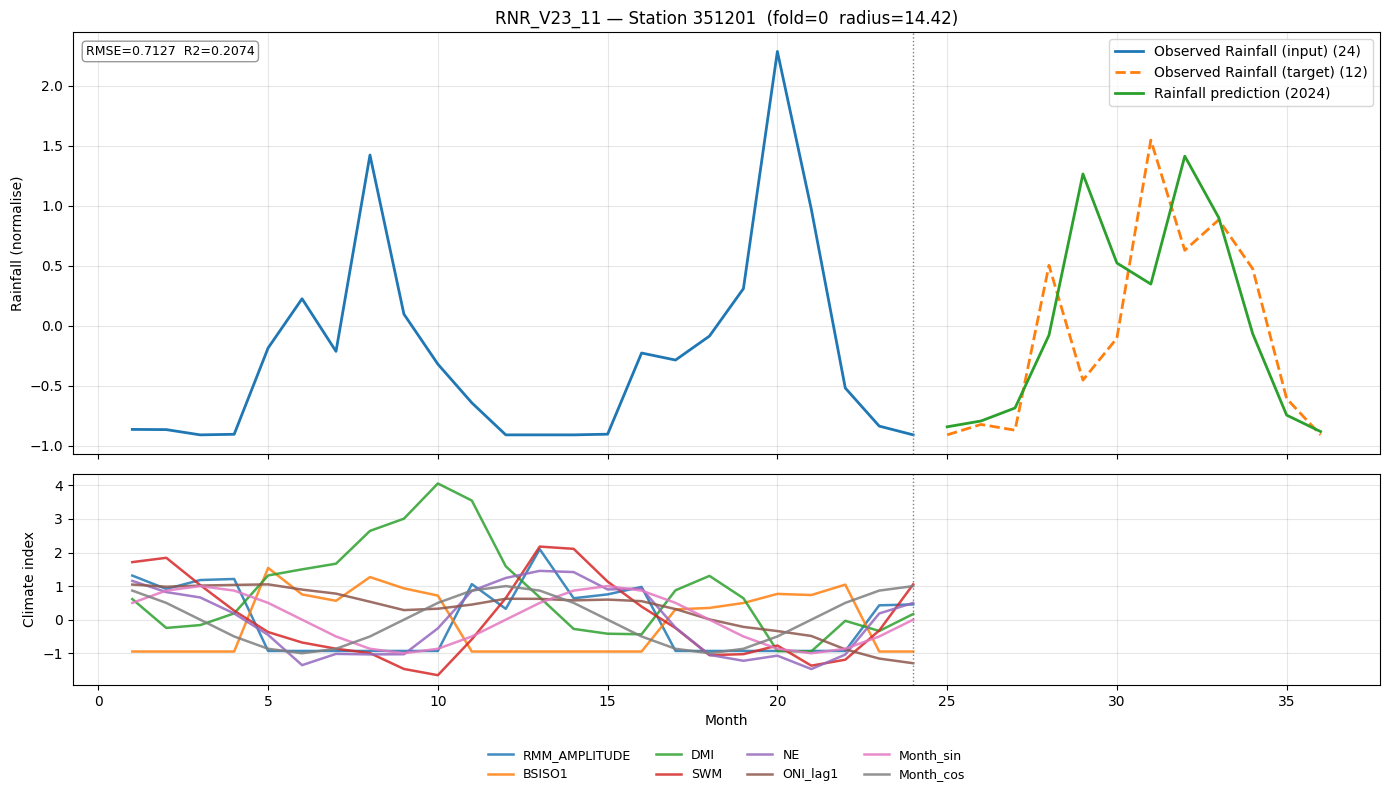

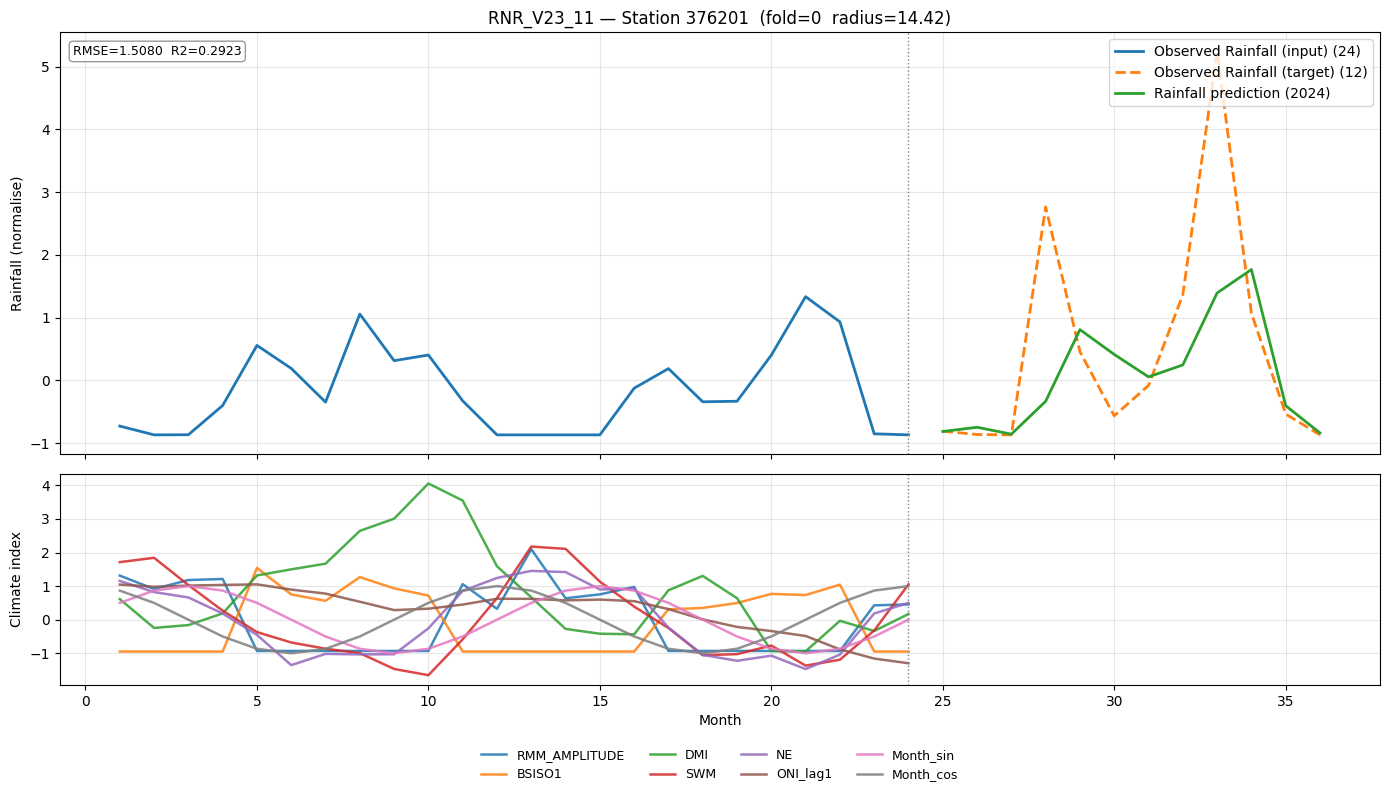

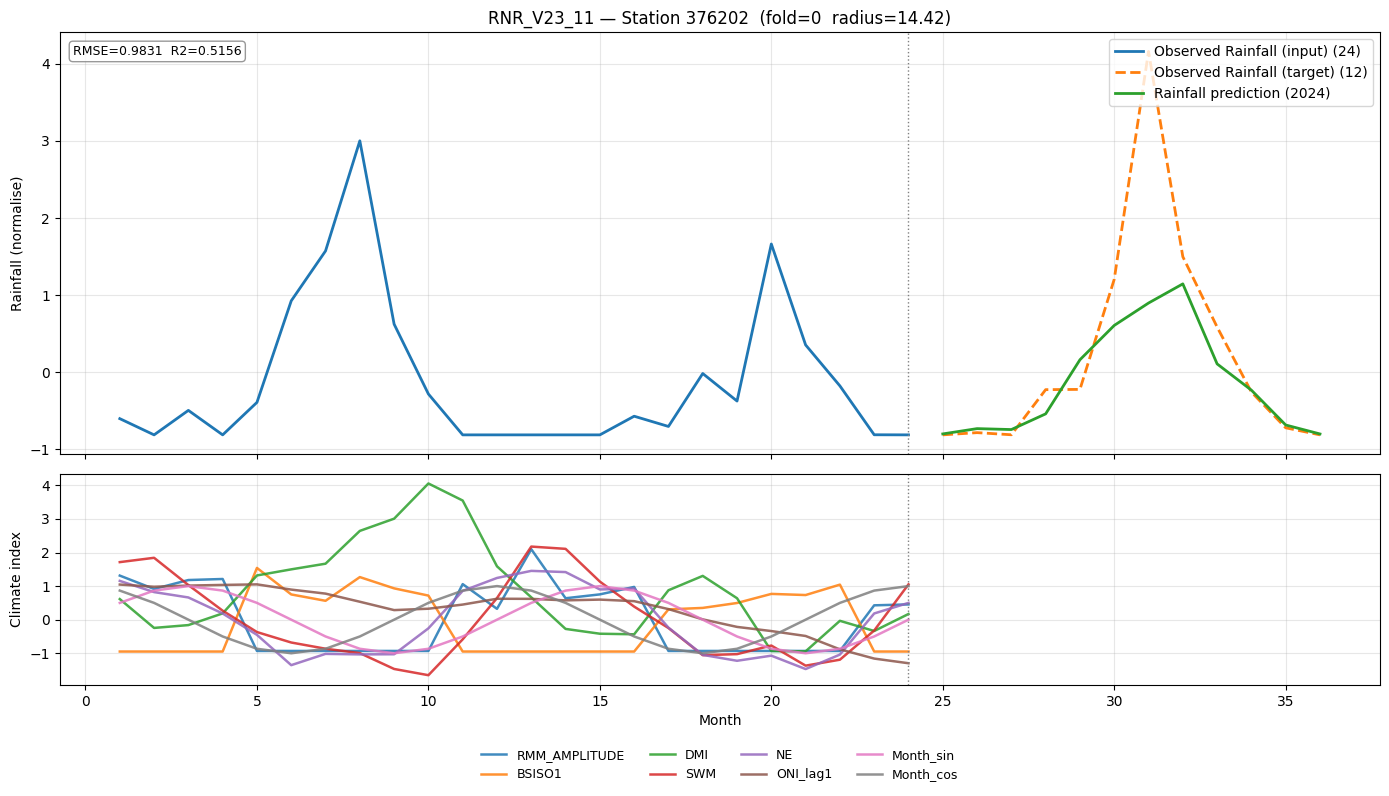

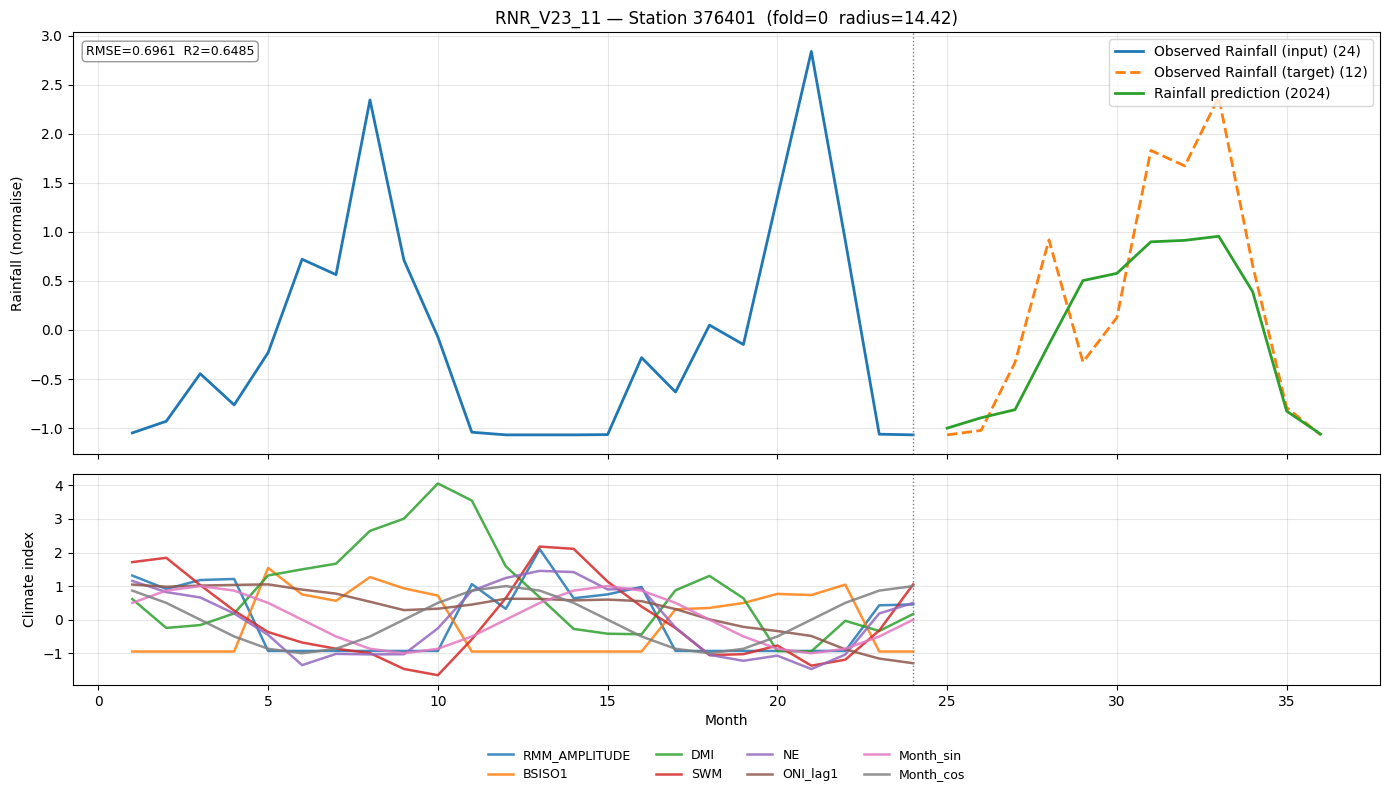

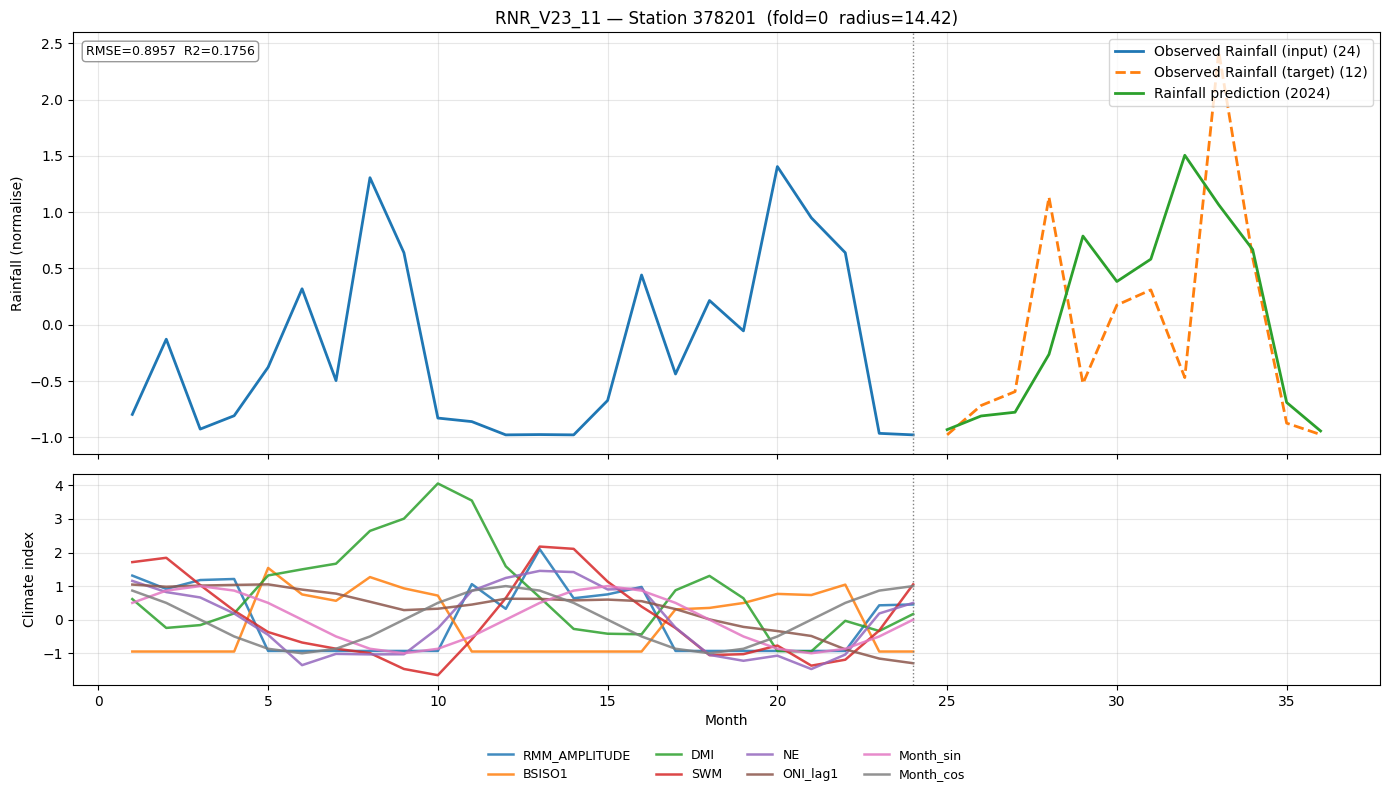

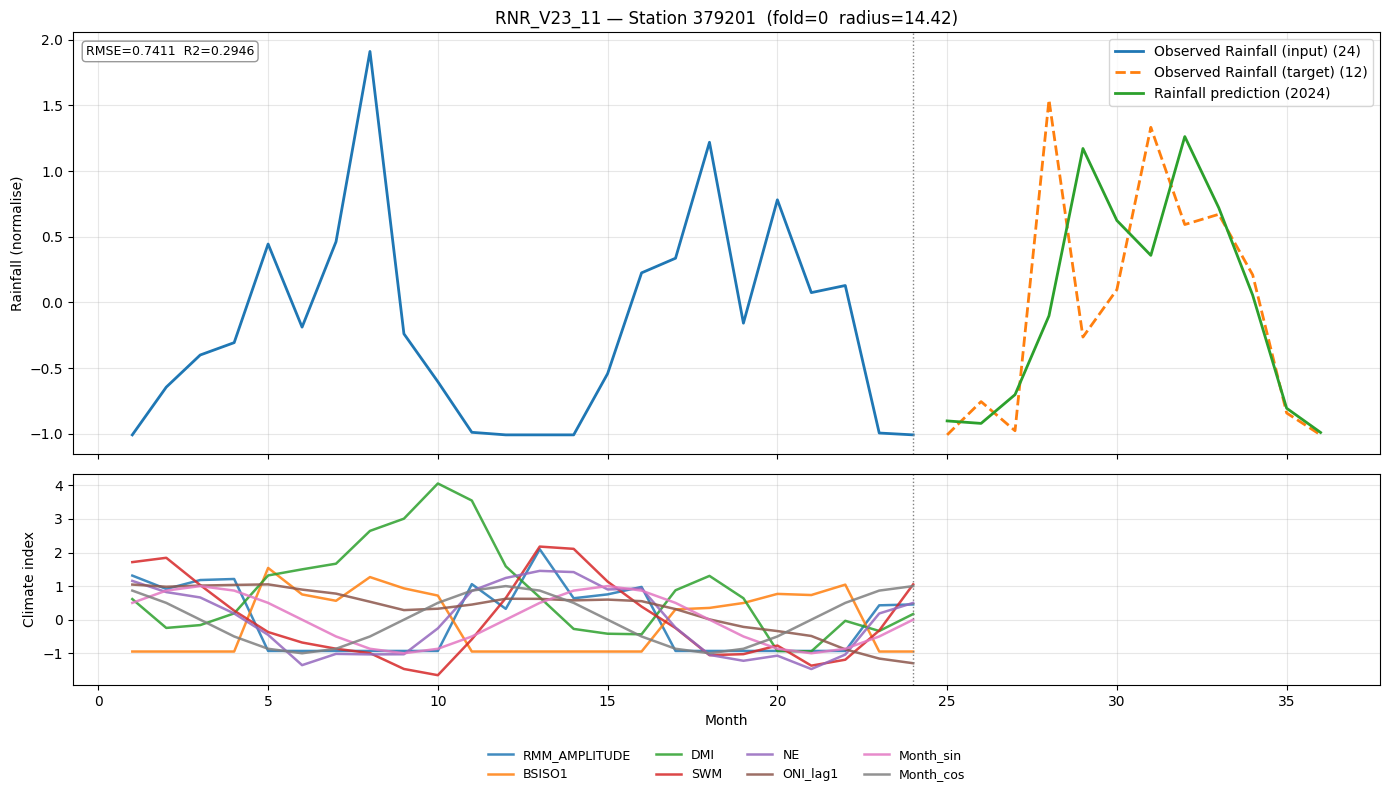

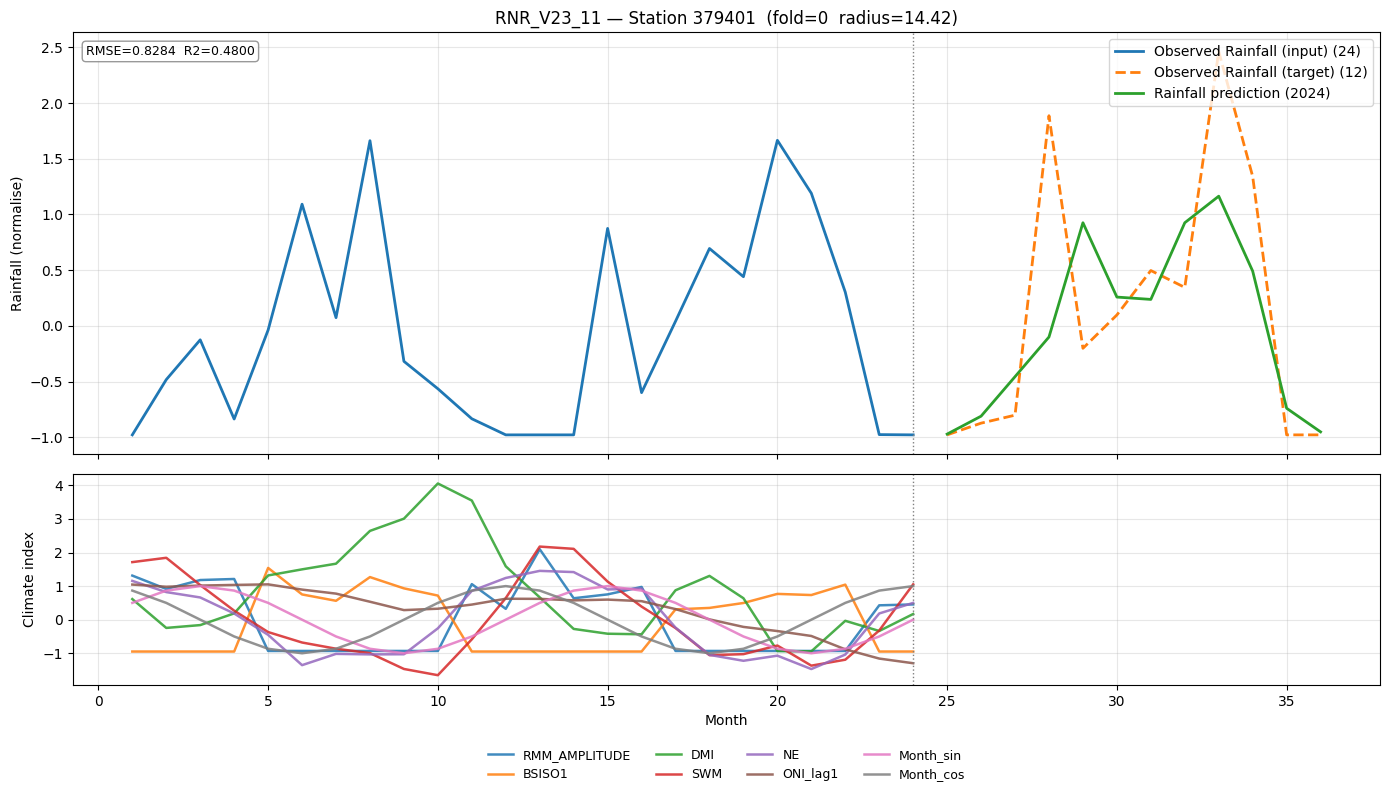


Visualising fold=1  best radius=14.56


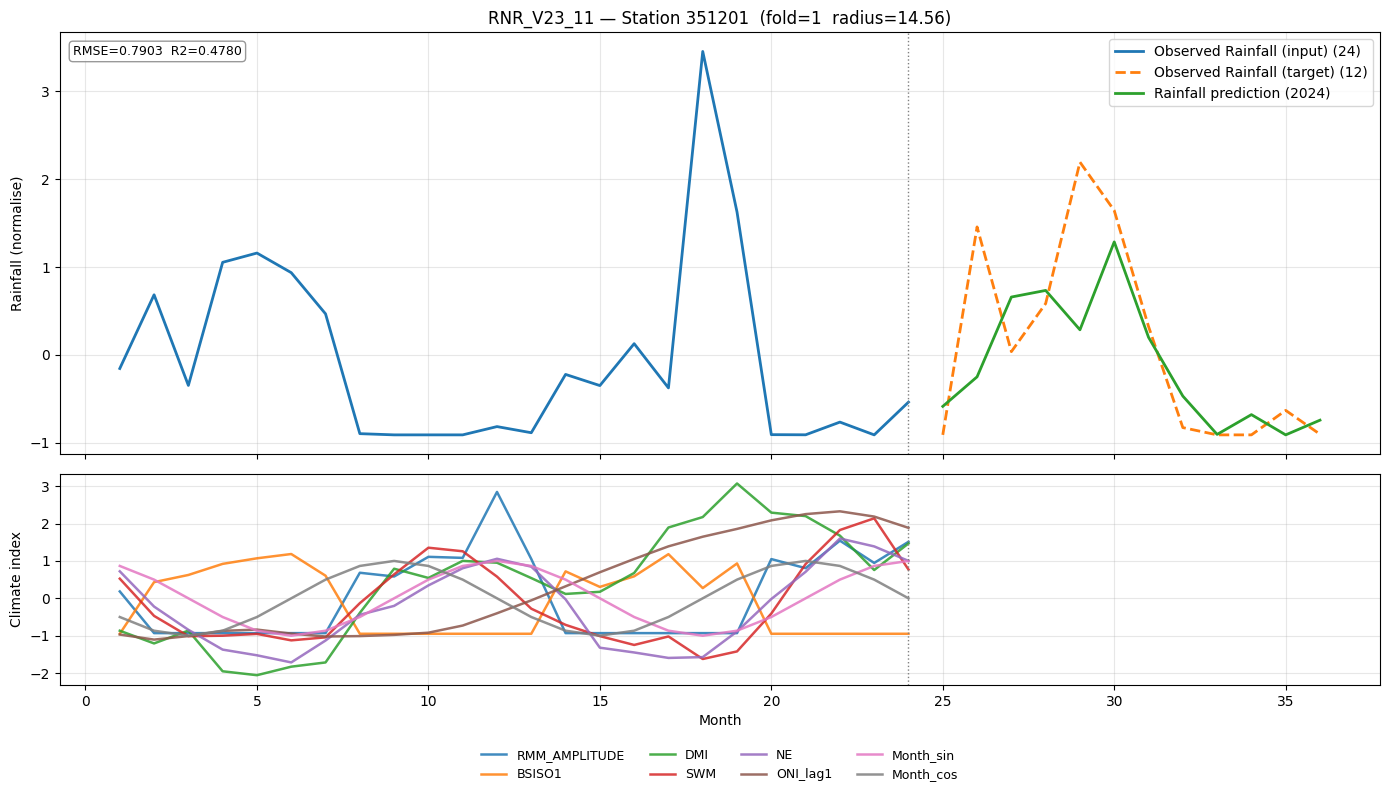

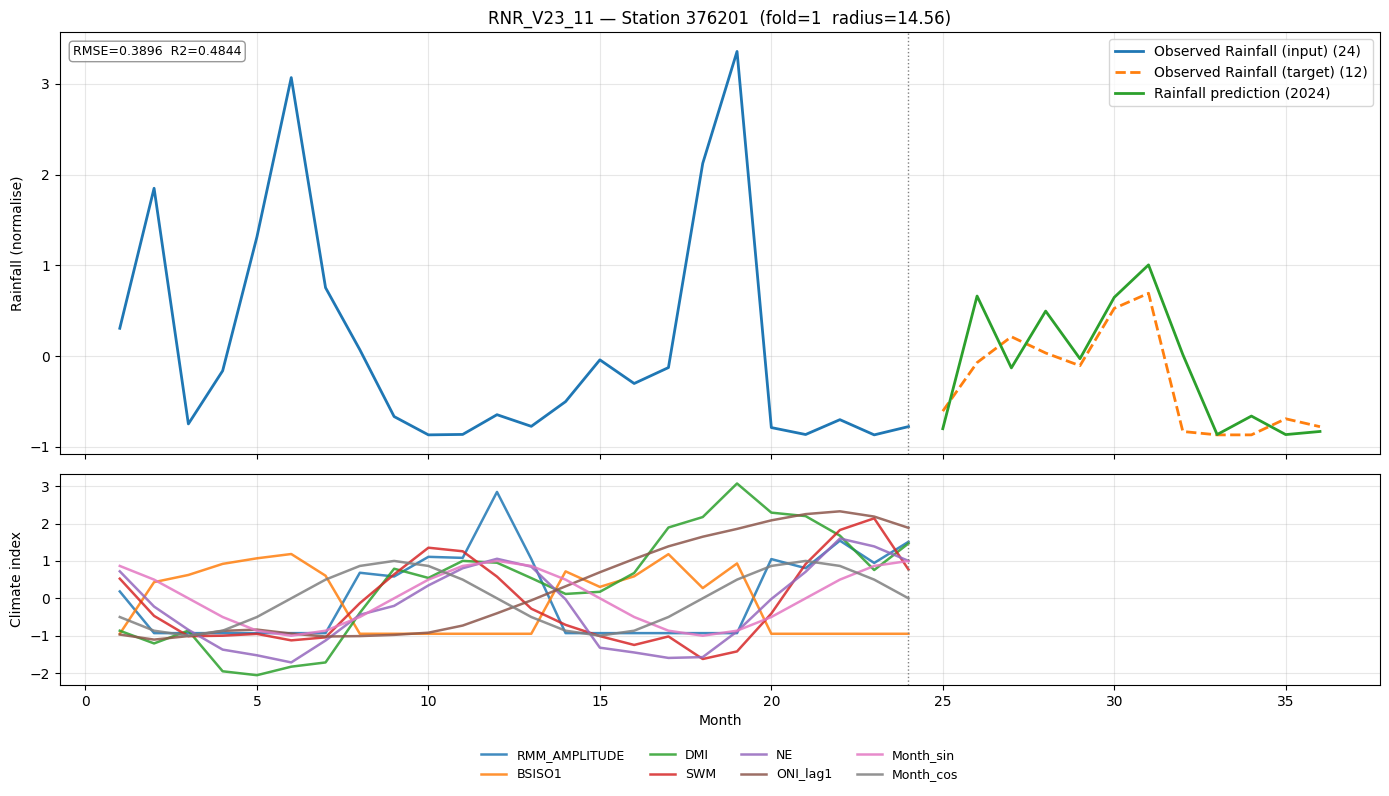

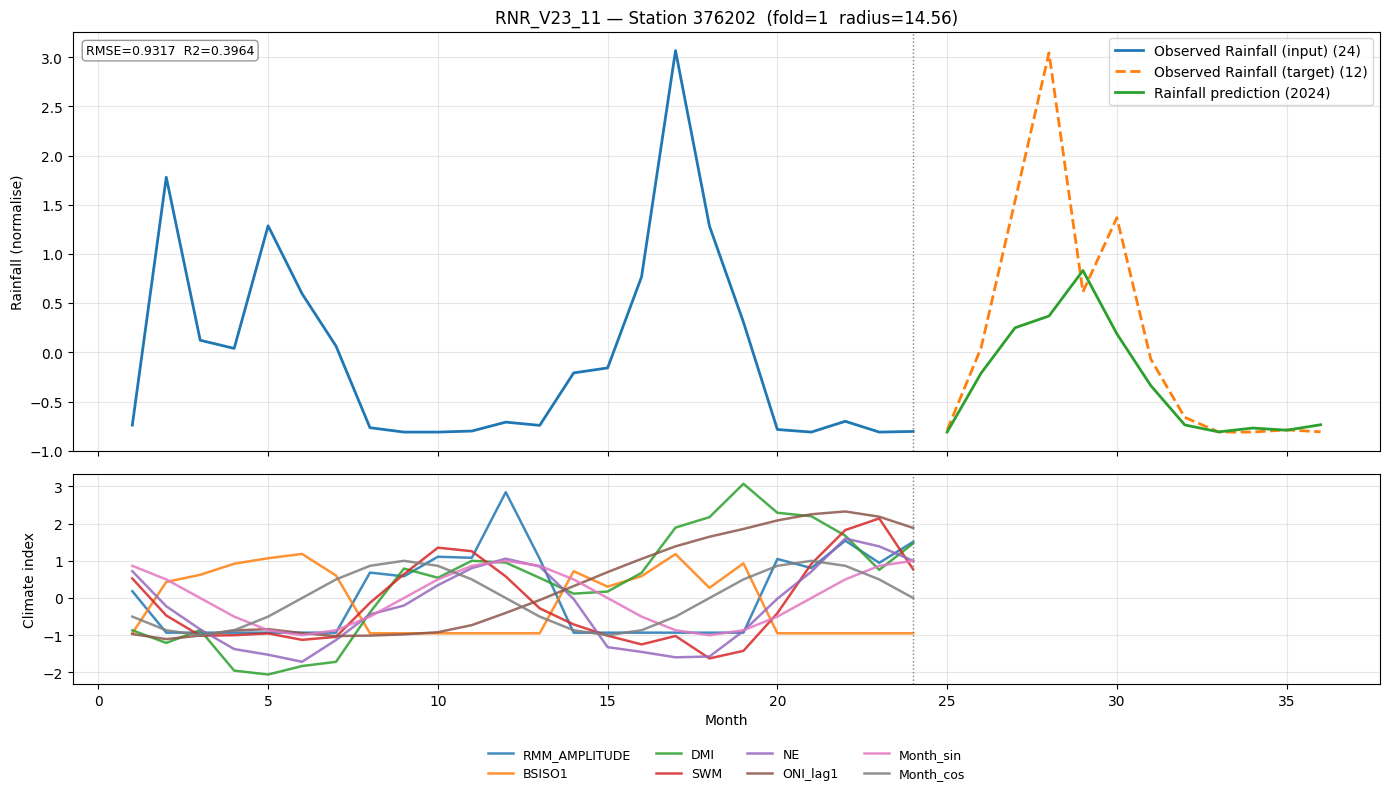

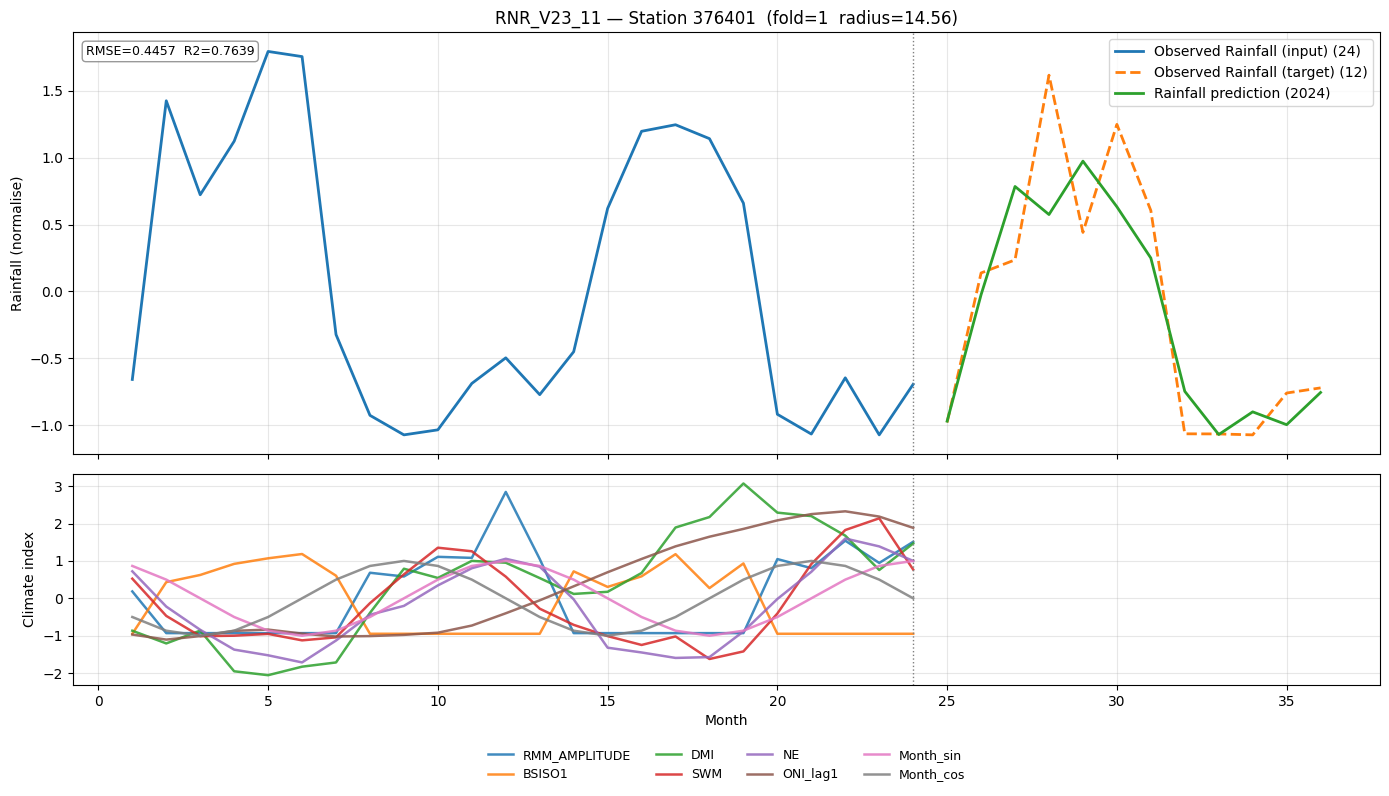

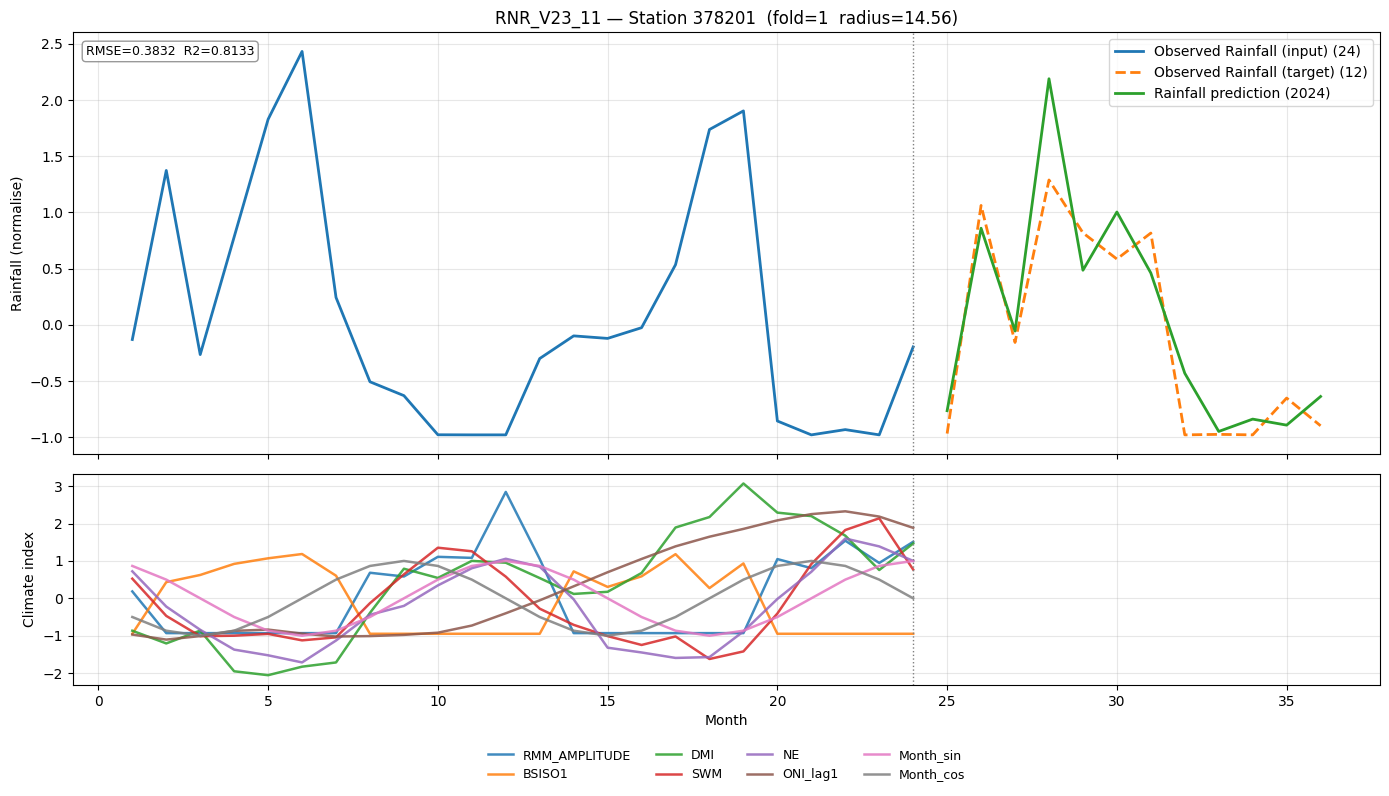

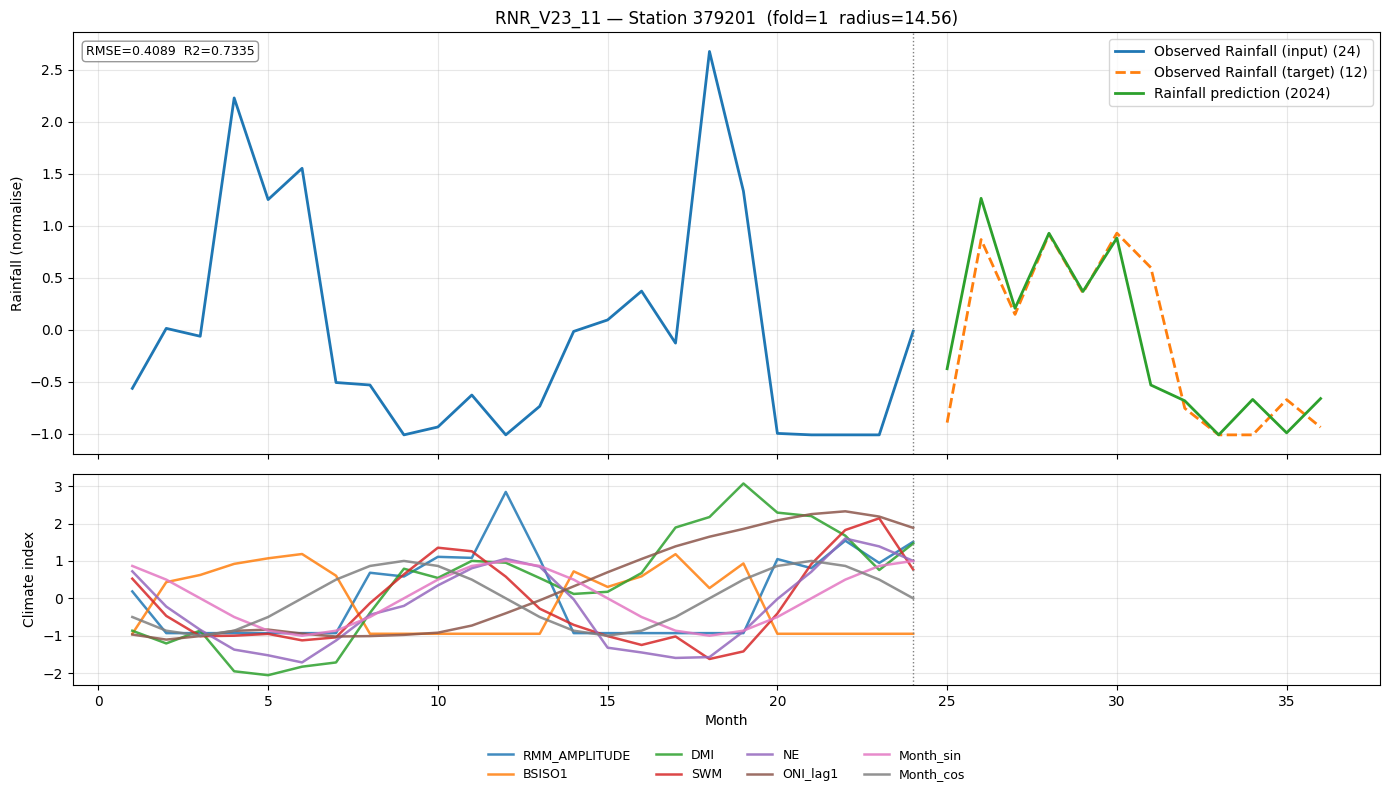

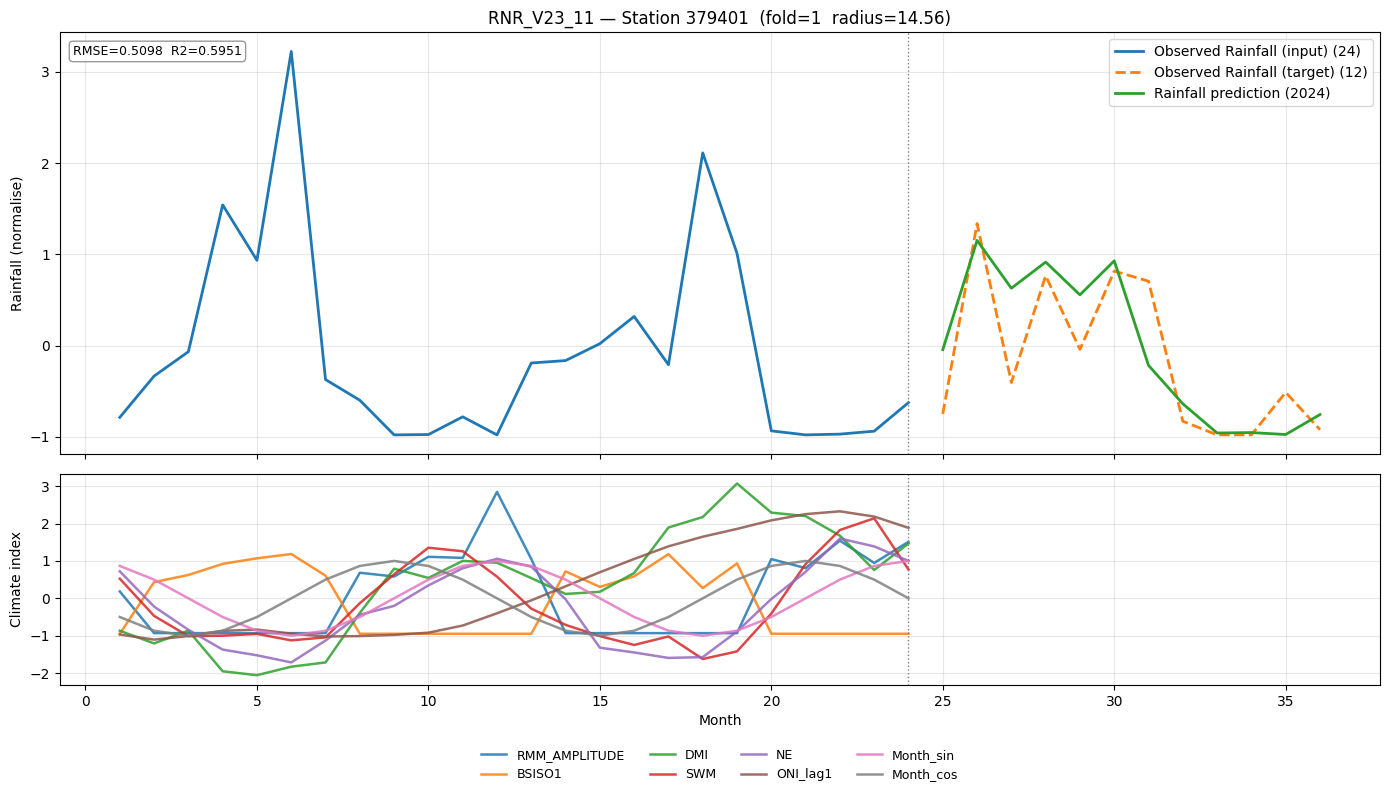

In [48]:
# -*- coding: utf-8 -*-
# RNR_V23_11_TMD_ALLcluster_clean.py
#
# ⚠ รันต่อจาก LSTM notebook — ต้องการตัวแปรเหล่านี้จาก cell ก่อนหน้า:
#   fold, cluster_station, climate_name_list, num_feature (nf),
#   window_size, horizon, k_fold_num, cluster, algo (จะ override),
#   node, station_names (ถ้ามี), scaler_Y
# ─────────────────────────────────────────────────────────────────

import time as countdown
import warnings
warnings.filterwarnings("ignore")
from sklearn.neighbors import RadiusNeighborsRegressor, NearestNeighbors

# ── RNR-specific config (override LSTM config เฉพาะที่ต่างกัน) ──
algo_rnr       = 'RNR_V23_11'
BASE           = '/content/drive/MyDrive/KKU_Workshop3'
radius_list    = None
weights_list   = ['distance']
algorithm_list = ['ball_tree']

# station_names อาจยังไม่มีใน LSTM cell — สร้างถ้าไม่มี
if 'station_names' not in dir():
    station_names = [node['Node'].iloc[i] for i in cluster_station]


# ── Rebuild fold ด้วย Val/Test range กว้างขึ้น ────────────────
# LSTM ใช้ val/test แค่ 2 ปี (24 เดือน) → ได้แค่ 1 sample
# RNR ต้องการ ≥ window+horizon = 36 เดือน → ขยายเป็น 4 ปี (48 เดือน)
_s    = pd.to_datetime(Y_rainfall_normalized_df.index.min())
_dmax = pd.to_datetime(Y_rainfall_normalized_df.index.max())   # ใช้จาก index โดยตรง
_rd   = lambda m: relativedelta(months=m)
_splits = [
    (_s+_rd(37*12+11), _s+_rd(35*12), _s+_rd(38*12+11), _s+_rd(36*12), _s+_rd(39*12+11)),
    (_s+_rd(40*12),    _s+_rd(38*12), _s+_rd(41*12+11), _s+_rd(39*12), _dmax),
]
fold_rnr = []
for et,sv,ev,st,ete in _splits:
    tr = [t[_s:et]  for t in list_table]
    va = [t[sv:ev]  for t in list_table]
    te = [t[st:ete] for t in list_table]
    # apply feature selection เหมือน LSTM
    tr = [df.iloc[:,position_all_index] for df in tr]
    va = [df.iloc[:,position_all_index] for df in va]
    te = [df.iloc[:,position_all_index] for df in te]
    fold_rnr.append([tr, te, va])

nf = num_feature   # alias สั้นกว่า
ns = len(cluster_station)
print(f"nf={nf}  stations={ns}  feat_dim={(nf+ns)*window_size}")


# ── Metrics (reuse accuracy2D_classic จาก LSTM cell) ─────────────
# nse_score, r2, mse, safe_mse ใช้ numpy ล้วน (ไม่ต้องการ torch)

def _mask(a, b):
    o, p = np.array(a).ravel(), np.array(b).ravel()
    m = ~(np.isnan(o) | np.isnan(p))
    return o[m], p[m]

def nse_np(obs, pred):
    o, p = _mask(obs, pred)
    d = np.sum((o - o.mean()) ** 2)
    return float('nan') if len(o) == 0 or d == 0 else float(1 - np.sum((o-p)**2) / d)

def r2_np(obs, pred):
    o, p = _mask(obs, pred)
    d = np.sum((o - o.mean()) ** 2)
    return float('nan') if len(o) == 0 or d == 0 else float(1 - np.sum((o-p)**2) / d)

def mse_np(yt, yp):
    o, p = _mask(yt, yp)
    return float('nan') if len(o) == 0 else float(np.mean((o-p)**2))

def acc2d_np(yp, yt):
    """accuracy2D_classic แต่รับ numpy (ไม่ต้องการ torch)"""
    yp, yt = np.array(yp).ravel(), np.array(yt).ravel()
    a = []
    for j, i in zip(yp, yt):
        if np.isnan(j) or np.isnan(i): continue
        a.append(1-min(1,abs((j-i)/i)) if i != 0 else
                 (1.0 if abs(j)+abs(i) == 0 else 1-min(1, 2*abs(j-i)/(abs(j)+abs(i)))))
    return np.array(a) if a else np.array([0.0])

def station_metrics(yt3, yp3, names, H):
    """(n,ns,H) → DataFrame per station + summary dict"""
    rows = []
    for si, sn in enumerate(names):
        o, p = yt3[:,si,:].ravel(), yp3[:,si,:].ravel()
        ms = mse_np(o,p)
        row = dict(station=sn, mse=ms,
                   rmse=float(np.sqrt(ms)) if not np.isnan(ms) else float('nan'),
                   r2=r2_np(o,p), nse=nse_np(o,p),
                   acc=float(np.mean(acc2d_np(p,o))*100),
                   coverage_pct=100*(1-int(np.isnan(p).sum())/max(len(p),1)))
        for m in range(H):
            row[f'acc_month{m+1}'] = float(np.mean(acc2d_np(yp3[:,si,m], yt3[:,si,m]))*100)
        rows.append(row)
    df = pd.DataFrame(rows)
    summ = {f'avg_{k}': float(np.nanmean(df[k]))
            for k in ['mse','rmse','r2','nse','acc']}
    return df, summ


# ── Model ─────────────────────────────────────────────────────────
def calibrate_radius(X, ks=(3, 5, 10)):
    """radius = p50 ของ k-th NN distance — ใช้ SEED ที่กำหนดไว้ให้ผลเหมือนเดิมทุกรัน"""
    rng  = np.random.default_rng(SEED)
    Xs   = X[rng.choice(len(X), min(300,len(X)), replace=False)].astype(np.float64)
    nbrs = NearestNeighbors(n_neighbors=max(ks)+1, algorithm='ball_tree').fit(Xs)
    D, _ = nbrs.kneighbors(Xs)
    cands = []
    for k in ks:
        p50 = np.percentile(D[:,k], 50)
        print(f"  k={k}: median k-th dist={p50:.2f}")
        cands.append(round(p50, 2))
    cands = sorted(set(cands))
    print(f"  radius candidates: {cands}")
    return cands

def build_dataset(fold_data, cs, nf_, W, H, noise=0.0):
    s0 = cs[0]; n = len(fold_data[s0]) - W - H + 1
    if n <= 0:
        print(f"  ⚠ {len(fold_data[s0])} rows < {W+H} needed → 0 samples")
        return np.empty((0,(nf_+len(cs))*W)), np.empty((0,len(cs)*H))
    Xl, yl = [], []
    for j in range(n):
        clim = np.array([fold_data[s0].iloc[j:j+W, ci].values
                         for ci in range(nf_)]).ravel()
        rx = np.array([fold_data[st].iloc[j:j+W, -1].values for st in cs]).ravel()
        ry = np.array([fold_data[st].iloc[j+W:j+W+H, -1].values for st in cs]).ravel()
        Xl.append(np.concatenate([clim, rx])); yl.append(ry)
    X = np.vstack(Xl).astype(np.float32)
    y = np.vstack(yl).astype(np.float32)
    if noise > 0:
        X += (np.random.randn(*X.shape) * noise).astype(np.float32)
    return X, y

class SafeRNR:
    def __init__(self, radius=5., weights='distance', algorithm='ball_tree', n_jobs=-1):
        self.radius=radius; self.weights=weights
        self.algorithm=algorithm; self.n_jobs=n_jobs
        self._m=None; self._mean=None

    def fit(self, X, y):
        self._m = RadiusNeighborsRegressor(
            radius=self.radius, weights=self.weights,
            algorithm=self.algorithm, n_jobs=self.n_jobs).fit(X, y)
        self._mean = np.nanmean(np.array(y), axis=0)
        return self

    def predict(self, X):
        raw = self._m.predict(np.array(X))
        if raw.ndim == 1: raw = raw.reshape(-1, 1)
        bad = np.isnan(raw).any(axis=1)
        if bad.any(): raw[bad] = self._mean
        return raw

    def diag(self, X):
        raw = self._m.predict(np.array(X))
        if raw.ndim == 1: raw = raw.reshape(-1, 1)
        n_empty = int(np.isnan(raw).any(axis=1).sum())
        counts  = np.array([len(r) for r in
                             self._m.radius_neighbors(np.array(X), return_distance=False)])
        return n_empty, float(counts.mean()), int(counts.max())


# ── Training loop ─────────────────────────────────────────────────
# Logic ที่ถูกต้อง:
#   ชั้น 1: หา radius ที่ดีที่สุดต่อ fold → ใช้ Val (mse_val ต่ำสุด)
#   ชั้น 2: เอา Test ของทุก fold (best radius แต่ละ fold) มาเฉลี่ยรวม
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

df2, df2_st   = [], []
best_per_fold = {}   # {fold_index: {'radius':r, 'model':mdl, 'summ_te':..., 'df_st_te':...}}
t0 = countdown.time()

for weights in weights_list:
 for algorithm in algorithm_list:
  for fi in range(k_fold_num):
    np.random.seed(SEED + fi); random.seed(SEED + fi)

    Xtr,ytr = build_dataset(fold_rnr[fi][0],cluster_station,nf,window_size,horizon,noise_level)
    Xte,yte = build_dataset(fold_rnr[fi][1],cluster_station,nf,window_size,horizon)
    Xva,yva = build_dataset(fold_rnr[fi][2],cluster_station,nf,window_size,horizon)
    print(f"\nFold {fi} | Train{Xtr.shape} Val{Xva.shape} Test{Xte.shape}")
    if any(x.shape[0]==0 for x in [Xtr,Xva,Xte]):
        print("  ⚠ empty split — skip"); continue

    r_list = calibrate_radius(Xtr) if radius_list is None else radius_list

    best_val_mse = float('inf')   # ติดตาม best radius ของ fold นี้

    for radius in r_list:
      print(f"\n  radius={radius}  fold={fi}  weights={weights}")
      mdl = SafeRNR(radius=radius, weights=weights, algorithm=algorithm).fit(Xtr, ytr)

      ne_v,ak_v,mk_v = mdl.diag(Xva)
      ne_t,ak_t,mk_t = mdl.diag(Xte)
      print(f"  Coverage: val={100*(1-ne_v/max(len(Xva),1)):.1f}%  "
            f"test={100*(1-ne_t/max(len(Xte),1)):.1f}%")
      print(f"  Avg neighbours: val={ak_v:.1f}(max={mk_v})  test={ak_t:.1f}(max={mk_t})")
      if ak_v > 50: print("  ⚠ over-smoothing (avg>50) → prediction แบน")

      # save model ทุก radius
      os.makedirs(f'{BASE}/pre_trained_models_v23', exist_ok=True)
      mp = (f'{BASE}/pre_trained_models_v23/model_{algo_rnr}_Fold={fi}'
            f'_nf={nf}_r={radius}_w={weights}_cluster={cluster}.pkl')
      pickle.dump(mdl, open(mp, 'wb'))

      # ── ชั้น 1: ประเมิน val → หา best radius ต่อ fold ──
      yv_p = mdl.predict(Xva)
      vm   = mse_np(yva, yv_p); vr2 = r2_np(yva, yv_p)
      vacc = float(np.mean(acc2d_np(yv_p, yva))*100)
      vnse = nse_np(yva, yv_p)
      print(f"  [Val]  MSE={vm:.4f}  R²={vr2:.4f}  Acc={vacc:.2f}%  NSE={vnse:.4f}")

      # test per-station (เก็บไว้ใช้ถ้า radius นี้เป็น best)
      yt_p  = mdl.predict(Xte)
      ytp3  = yt_p.reshape(len(Xte), ns, horizon)
      yt3   = yte.reshape(len(Xte),  ns, horizon)
      df_st_te, summ_te = station_metrics(yt3, ytp3, station_names, horizon)
      df_st_te[['fold_index','radius','split']] = fi, radius, 'test'
      print(f"\n  [Test per station]\n"
            f"{df_st_te[['station','mse','rmse','r2','nse','acc']].to_string(index=False)}")
      print(f"  [Test avg] MSE={summ_te['avg_mse']:.4f}  RMSE={summ_te['avg_rmse']:.4f}  "
            f"R²={summ_te['avg_r2']:.4f}  Acc={summ_te['avg_acc']:.2f}%  "
            f"NSE={summ_te['avg_nse']:.4f}")

      time_acc = np.array([
          float(np.mean(acc2d_np(ytp3[:,:,m].ravel(), yt3[:,:,m].ravel()))*100)
          for m in range(horizon)])
      print(f"  Per-month Acc: {np.round(time_acc, 2)}")

      # train metrics (clean)
      Xtr_c,ytr_c = build_dataset(fold_rnr[fi][0],cluster_station,nf,window_size,horizon)
      ytr_p = mdl.predict(Xtr_c)
      df_st_tr, summ_tr = station_metrics(
          ytr_c.reshape(len(Xtr_c),ns,horizon),
          ytr_p.reshape(len(Xtr_c),ns,horizon), station_names, horizon)
      df_st_tr[['fold_index','radius','split']] = fi, radius, 'train'

      df_st_va, _ = station_metrics(
          yva.reshape(len(Xva),ns,horizon),
          yv_p.reshape(len(Xva),ns,horizon), station_names, horizon)
      df_st_va[['fold_index','radius','split']] = fi, radius, 'val'

      df2_st.extend(df_st_tr.to_dict('records'))
      df2_st.extend(df_st_va.to_dict('records'))
      df2_st.extend(df_st_te.to_dict('records'))

      # aggregate row
      row = np.hstack(([fi, nf, window_size, cluster, radius,
                         weights_list.index(weights), algorithm_list.index(algorithm),
                         summ_tr['avg_acc'], summ_tr['avg_mse'], summ_tr['avg_r2'],
                         summ_te['avg_acc'], summ_te['avg_mse'], summ_te['avg_rmse'],
                         summ_te['avg_r2'], summ_te['avg_nse'], vm, vr2], time_acc))
      df2.append(row)

      # ── เลือก best radius ต่อ fold จาก mse_val ──
      if vm < best_val_mse:
          best_val_mse = vm
          best_per_fold[fi] = {
              'radius': radius, 'weights': weights,
              'summ_te': summ_te, 'df_st_te': df_st_te.copy(),
              'time_acc': time_acc, 'val_mse': vm, 'val_r2': vr2,
          }
          print(f"  ★ New best radius for fold {fi}: {radius} (val_mse={vm:.4f})")

    print(f"\n  → Best radius for fold {fi} = {best_per_fold[fi]['radius']} "
          f"(val_mse={best_per_fold[fi]['val_mse']:.4f})")

    cols = ['fold_index','num_feature','window_size','cluster','radius',
            'weights_idx','algorithm_idx','acc_train','mse_train','r2_train',
            'acc_test','mse_test','rmse_test','r2_test','nse_score_test',
            'mse_val','r2_val'] + [f'acc_month{m+1}' for m in range(horizon)]
    df_out = pd.DataFrame(df2, columns=cols)
    os.makedirs(f'{BASE}/metric_results_v23', exist_ok=True)
    df_out.to_csv(
        f'{BASE}/metric_results_v23/predict_{algo_rnr}_cluster={cluster}_nf={nf}.csv',
        index=False)
    pd.DataFrame(df2_st).to_csv(
        f'{BASE}/metric_results_v23/predict_{algo_rnr}_cluster={cluster}_per_station.csv',
        index=False)
    print(f"  ✔ CSVs saved")

elapsed = countdown.time() - t0
print(f"\nTotal: {elapsed:.1f}s")
pd.DataFrame([{'cluster':cluster,'time':elapsed}]).to_csv(
    f'{BASE}/metric_results_v23/time_{algo_rnr}_cluster={cluster}.csv', index=False)

# ── ชั้น 2: เฉลี่ย Test ของทุก fold (best radius แต่ละ fold) ──────
print(f"\n{'='*65}")
print(f"  FINAL RESULT — average test across ALL folds")
print(f"  (best radius per fold selected by lowest val_mse)")
print(f"{'='*65}")
for fi, info in best_per_fold.items():
    print(f"  Fold {fi}: best radius={info['radius']}  val_mse={info['val_mse']:.4f}")
print()

# รวม df_st_te ของ best radius แต่ละ fold แล้วเฉลี่ยรายสถานี
all_best_te = pd.concat([info['df_st_te'] for info in best_per_fold.values()], ignore_index=True)

final_rows = []
for sn in station_names:
    sub = all_best_te[all_best_te['station'] == sn]
    row = {'station': sn,
           'mse':  float(sub['mse'].mean()),
           'rmse': float(sub['rmse'].mean()),
           'r2':   float(sub['r2'].mean()),
           'nse':  float(sub['nse'].mean()),
           'acc':  float(sub['acc'].mean())}
    for m in range(horizon):
        row[f'acc_month{m+1}'] = float(sub[f'acc_month{m+1}'].mean())
    final_rows.append(row)

df_final = pd.DataFrame(final_rows)

print(f"  {'Station':<12}{'MSE':>8}{'RMSE':>8}{'R²':>8}{'NSE':>8}{'Acc%':>8}")
print(f"  {'-'*52}")
for _, r in df_final.iterrows():
    print(f"  {str(r['station']):<12}{r['mse']:>8.4f}{r['rmse']:>8.4f}"
          f"{r['r2']:>8.4f}{r['nse']:>8.4f}{r['acc']:>7.2f}%")

avg = df_final[['mse','rmse','r2','nse','acc']].mean()
print(f"  {'-'*52}")
print(f"  {'AVERAGE':<12}{avg['mse']:>8.4f}{avg['rmse']:>8.4f}"
      f"{avg['r2']:>8.4f}{avg['nse']:>8.4f}{avg['acc']:>7.2f}%")
print(f"{'='*65}")

# per-month avg across all folds
final_time_acc = np.array([df_final[f'acc_month{m+1}'].mean() for m in range(horizon)])
print(f"\n  Per-month Acc (avg all folds): {np.round(final_time_acc, 2)}")

# บันทึก final result
df_final['cluster'] = cluster
df_final.to_csv(
    f'{BASE}/metric_results_v23/final_{algo_rnr}_cluster={cluster}_avg_folds.csv',
    index=False)
print(f"\n  ✔ Final result saved")


# ── Visualisation — snapshot สุดท้าย แยกสถานี ────────────────────
if not best_per_fold:
    print("⚠ No results.")
else:
    # แสดงกราฟสำหรับแต่ละ fold (best radius ของ fold นั้น)
    for fi, info in best_per_fold.items():
        brad = info['radius']
        bw   = info['weights']

        mdl_best = pickle.load(open(
            f'{BASE}/pre_trained_models_v23/model_{algo_rnr}_Fold={fi}'
            f'_nf={nf}_r={brad}_w={bw}_cluster={cluster}.pkl', 'rb'))
        print(f"\nVisualising fold={fi}  best radius={brad}")

        Xv, yv = build_dataset(fold_rnr[fi][1], cluster_station, nf, window_size, horizon)
        co      = nf * window_size
        xs_last = Xv[-1]; ys_last = yv[-1]
        pred_last   = mdl_best.predict(xs_last.reshape(1,-1))[0]
        x_clim_last = xs_last[:co].reshape(nf, window_size)
        tw = np.arange(1, window_size + 1)
        th = np.arange(window_size + 1, window_size + horizon + 1)

        for si in range(ns):
            sn     = station_names[si]
            x_rain = xs_last[co + si*window_size : co + (si+1)*window_size]
            y_rain = ys_last[si*horizon : (si+1)*horizon]
            y_pred = pred_last[si*horizon : (si+1)*horizon]

            snap_rmse = float(np.sqrt(mse_np(y_rain, y_pred)))
            snap_r2   = r2_np(y_rain, y_pred)

            fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                     gridspec_kw={"height_ratios": [2, 1]})

            axes[0].plot(tw, x_rain, lw=2,
                         label=f"Observed Rainfall (input) ({window_size})")
            axes[0].plot(th, y_rain, lw=2, ls='--',
                         label=f"Observed Rainfall (target) ({horizon})")
            axes[0].plot(th, y_pred, lw=2, label="Rainfall prediction (2024)")
            axes[0].axvline(window_size, color='gray', ls=':', lw=1)
            axes[0].set_ylabel("Rainfall (normalise)")
            axes[0].set_title(f"{algo_rnr} — Station {sn}  (fold={fi}  radius={brad})")
            axes[0].text(0.01, 0.97,
                         f"RMSE={snap_rmse:.4f}  R2={snap_r2:.4f}",
                         transform=axes[0].transAxes, fontsize=9,
                         verticalalignment='top',
                         bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                                   edgecolor='gray', alpha=0.8))
            axes[0].legend(loc='upper right'); axes[0].grid(alpha=0.3)

            for ci, nm in enumerate(climate_name_list):
                axes[1].plot(tw, x_clim_last[ci], lw=1.8, alpha=0.85, label=nm)
            axes[1].axvline(window_size, color='gray', ls=':', lw=1)
            axes[1].set_ylabel("Climate index"); axes[1].set_xlabel("Month")
            axes[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.25),
                           ncol=min(4, nf), fontsize=9, frameon=False)
            axes[1].grid(alpha=0.3)

            plt.tight_layout(); plt.show()

Best performing station overall (based on average accuracy): 376202.0

  VISUALISING PREDICTIONS FOR BEST STATION: 376202.0

Visualising for best station 376202.0 in fold=0 with radius=14.42


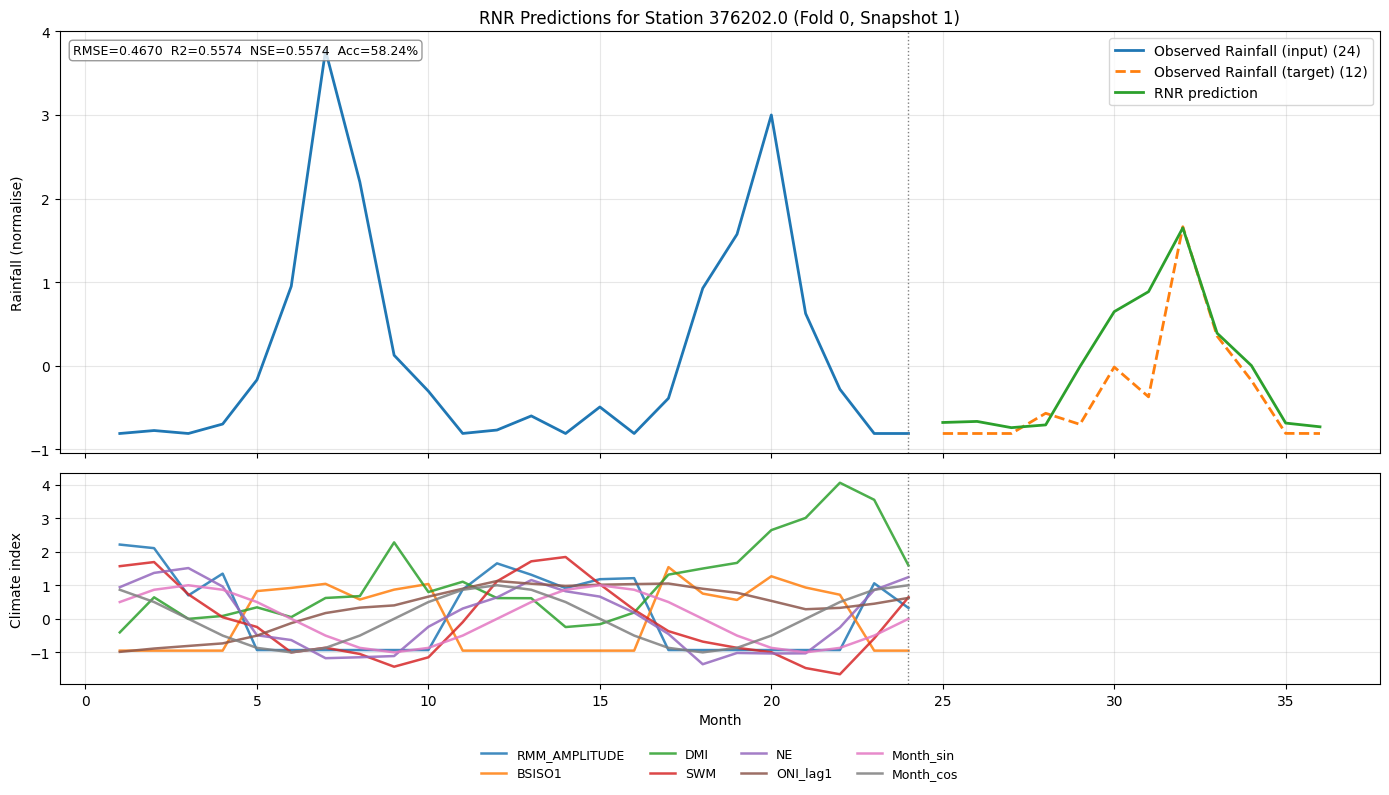

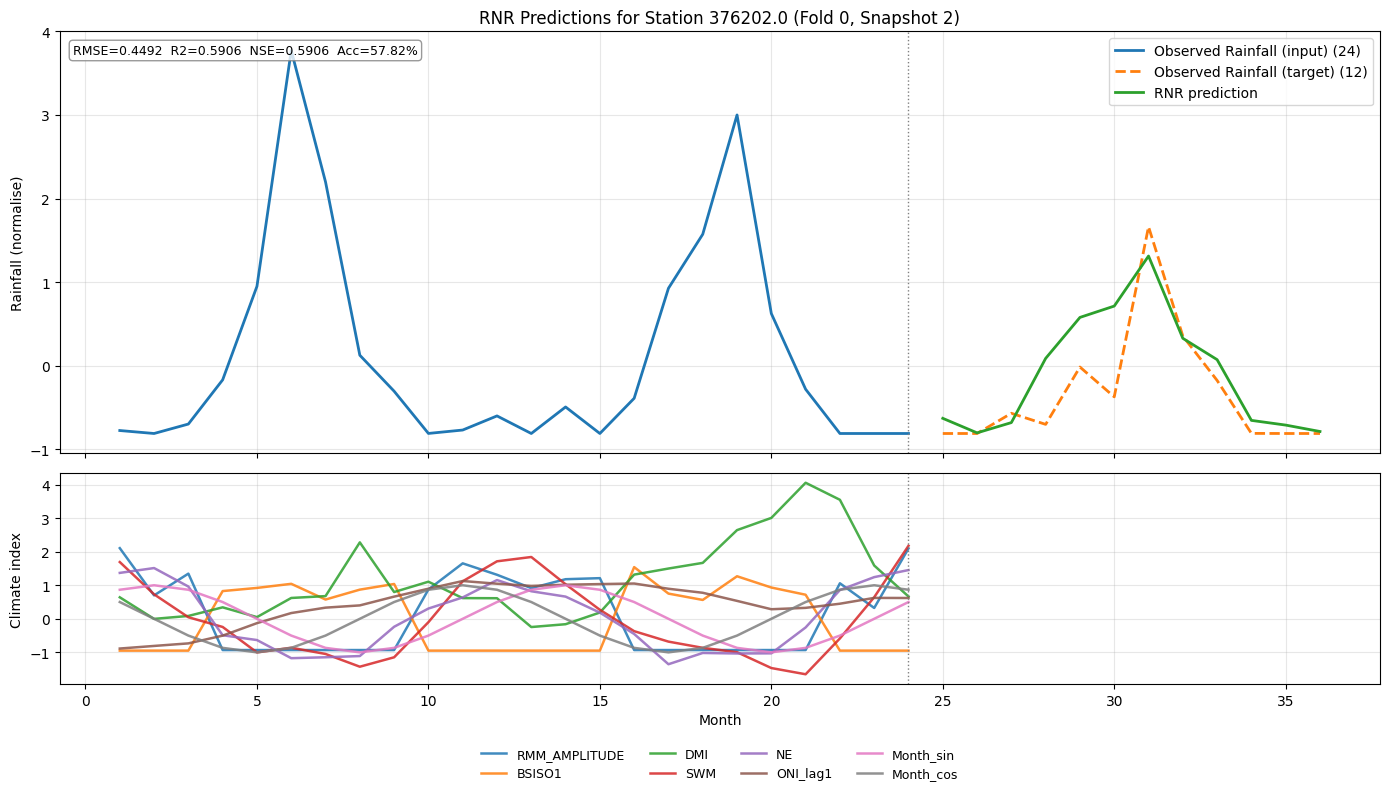

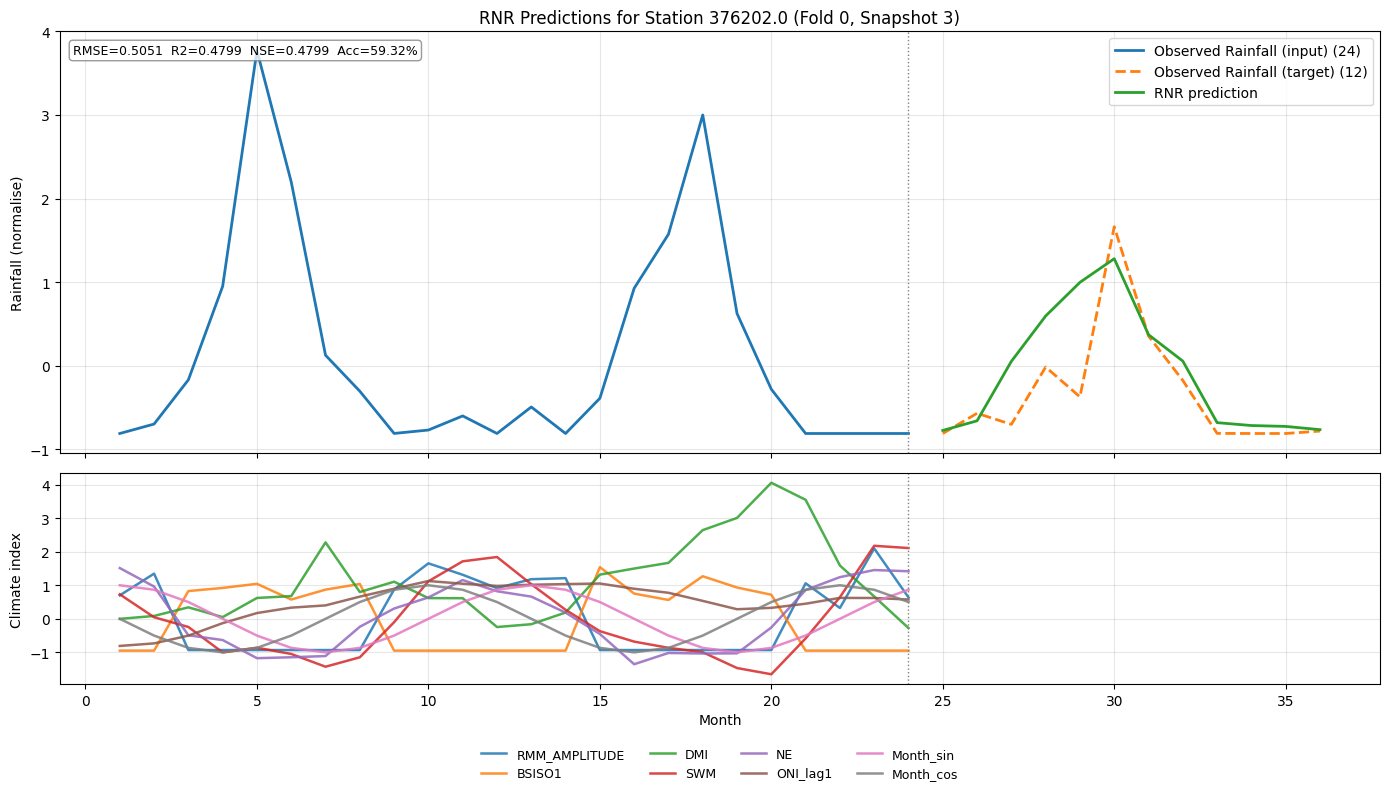


Visualising for best station 376202.0 in fold=1 with radius=14.56


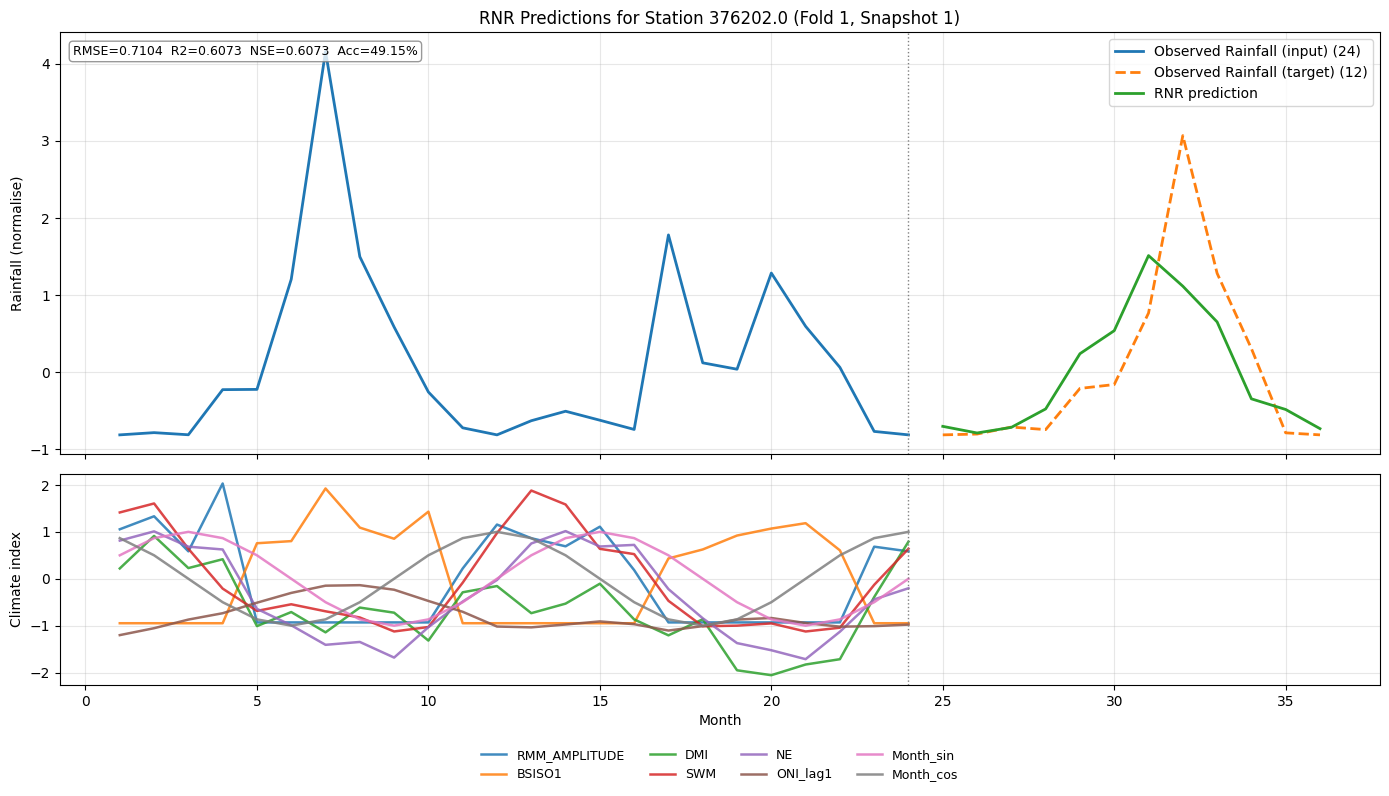

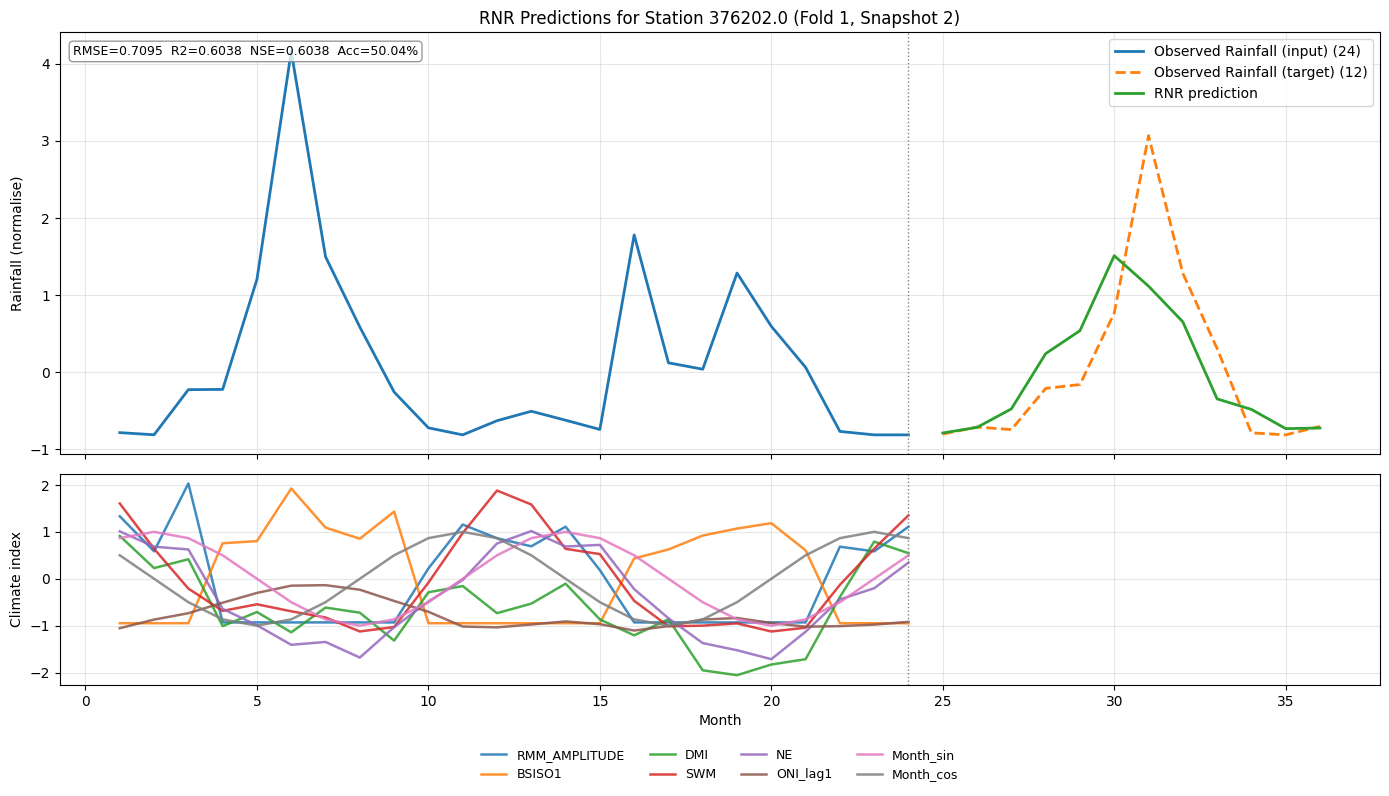

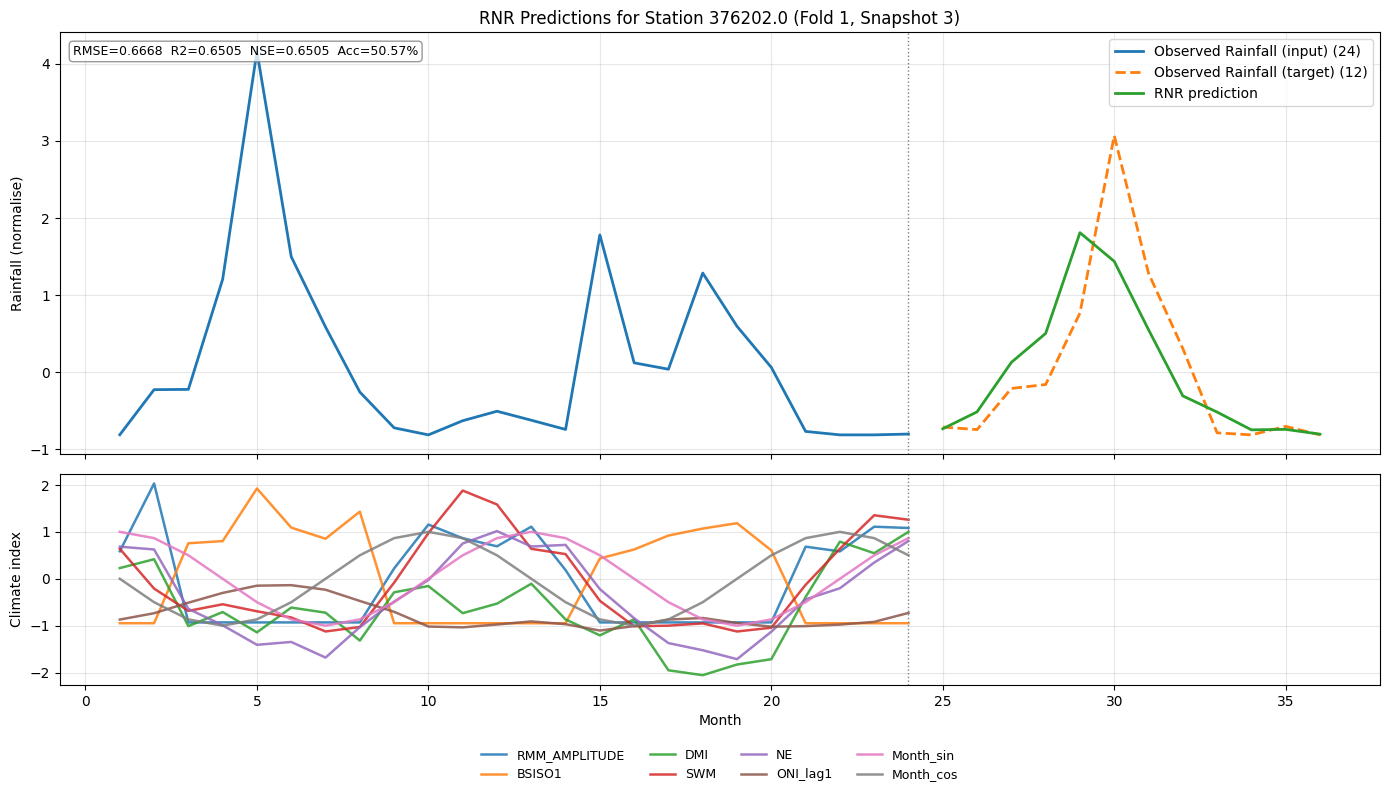

In [51]:
# Identify the best station based on average 'acc' across all folds
# df_final contains the average metrics per station across all folds
best_station_row = df_final.loc[df_final['acc'].idxmax()]
best_station_id = best_station_row['station']
print(f"Best performing station overall (based on average accuracy): {best_station_id}")

# Ensure algo_rnr, BASE, nf (num_feature), ns (len(cluster_station)) are accessible
# These should already be defined from previous cells

# Find the local index of the best_station_id within the cluster_station list
# This is needed to select the correct slice from the 3D prediction/true arrays
best_station_local_idx = station_names.index(best_station_id)

print(f"\n{'='*65}")
print(f"  VISUALISING PREDICTIONS FOR BEST STATION: {best_station_id}")
print(f"{'='*65}")

for fi in range(k_fold_num): # Iterate through each fold
    # Get the best radius and other parameters for this specific fold
    info = best_per_fold[fi]
    brad = info['radius']
    bw   = info['weights']
    # Assuming algorithm is always 'ball_tree' from algorithm_list[0] as configured
    balg = algorithm_list[0]

    # Construct the path to the best model for this fold
    mdl_best_path = (
        f'{BASE}/pre_trained_models_v23/model_{algo_rnr}_Fold={fi}'
        f'_nf={nf}_r={brad}_w={bw}_cluster={cluster}.pkl'
    )

    # Load the best model for this fold
    with open(mdl_best_path, 'rb') as f:
        mdl_best = pickle.load(f)

    print(f"\nVisualising for best station {best_station_id} in fold={fi} with radius={brad}")

    # Rebuild the test dataset for this specific fold (using fold_rnr for consistent data ranges)
    X_fold_test, y_fold_test_true = build_dataset(fold_rnr[fi][1], cluster_station, nf, window_size, horizon, noise=0.0)

    # Make predictions for the entire test set of this fold
    y_fold_test_pred = mdl_best.predict(X_fold_test)

    # Reshape predictions and true values to 3D (samples, stations, horizon)
    y_fold_test_true_3d = y_fold_test_true.reshape(len(X_fold_test), ns, horizon)
    y_fold_test_pred_3d = y_fold_test_pred.reshape(len(X_fold_test), ns, horizon)

    # Extract the relevant data for the best station
    # Visualize a few snapshots from the test set for the best station
    num_snapshots_to_vis = min(len(X_fold_test), 3) # Visualize first 3 snapshots

    for snap_idx in range(num_snapshots_to_vis):
        x_snapshot = X_fold_test[snap_idx]
        y_rain_true_station = y_fold_test_true_3d[snap_idx, best_station_local_idx, :]
        y_rain_pred_station = y_fold_test_pred_3d[snap_idx, best_station_local_idx, :]

        # Extract rain input window for this specific station
        co = nf * window_size # Climate offset
        x_rain_input = x_snapshot[co + best_station_local_idx * window_size : co + (best_station_local_idx + 1) * window_size]

        # Extract climate indices for this snapshot
        x_clim_last = x_snapshot[:co].reshape(nf, window_size)

        # Calculate metrics for this specific snapshot and station
        snap_rmse = float(np.sqrt(mse_np(y_rain_true_station, y_rain_pred_station)))
        snap_r2   = r2_np(y_rain_true_station, y_rain_pred_station)
        snap_nse  = nse_np(y_rain_true_station, y_rain_pred_station)
        snap_acc  = float(np.mean(acc2d_np(y_rain_pred_station, y_rain_true_station))*100)

        # Plotting
        fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                 gridspec_kw={"height_ratios": [2, 1]})

        t_window = np.arange(1, window_size + 1)
        t_horizon = np.arange(window_size + 1, window_size + horizon + 1)

        # Top plot: Rainfall
        axes[0].plot(t_window, x_rain_input, lw=2,
                     label=f"Observed Rainfall (input) ({window_size})")
        axes[0].plot(t_horizon, y_rain_true_station, lw=2, ls='--',
                     label=f"Observed Rainfall (target) ({horizon})")
        axes[0].plot(t_horizon, y_rain_pred_station, lw=2,
                     label="RNR prediction")
        axes[0].axvline(window_size, color='gray', ls=':', lw=1)
        axes[0].set_ylabel("Rainfall (normalise)")
        axes[0].set_title(f"RNR Predictions for Station {best_station_id} (Fold {fi}, Snapshot {snap_idx+1})")
        axes[0].text(0.01, 0.97,
                     f"RMSE={snap_rmse:.4f}  R2={snap_r2:.4f}  NSE={snap_nse:.4f}  Acc={snap_acc:.2f}%",
                     transform=axes[0].transAxes, fontsize=9,
                     verticalalignment='top',
                     bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                               edgecolor='gray', alpha=0.8))
        axes[0].legend(loc='upper right'); axes[0].grid(alpha=0.3)

        # Bottom plot: Climate indices
        for ci, nm in enumerate(climate_name_list):
            axes[1].plot(t_window, x_clim_last[ci], lw=1.8, alpha=0.85, label=nm)
        axes[1].axvline(window_size, color='gray', ls=':', lw=1)
        axes[1].set_ylabel("Climate index"); axes[1].set_xlabel("Month")
        axes[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.25),
                       ncol=min(4, nf), fontsize=9, frameon=False)
        axes[1].grid(alpha=0.3)

        plt.tight_layout(); plt.show()



Fold 0 — best station: 376401  NSE=0.6494  Acc=52.94%

Fold 1 — best station: 376401  NSE=0.7209  Acc=53.30%


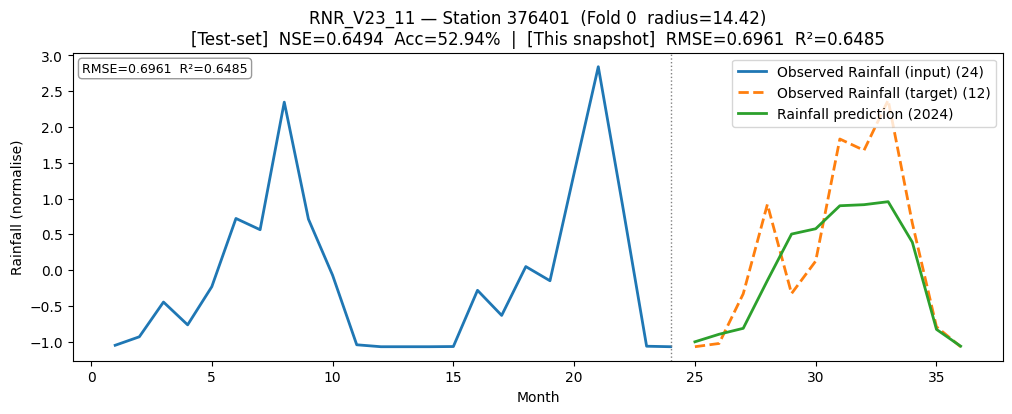

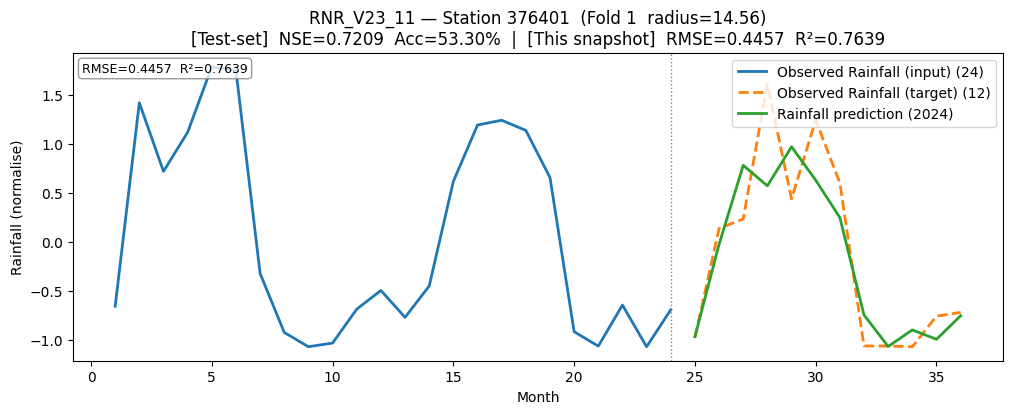

In [52]:
# ── กราฟ prediction ของสถานีที่ดีที่สุด แยกแต่ละ fold ──────────
# ดู station ที่ NSE สูงสุดในแต่ละ fold แล้ว plot snapshot สุดท้าย

import matplotlib.pyplot as plt
import numpy as np

for fi, info in best_per_fold.items():
    brad = info['radius']
    bw   = info['weights']

    # โหลด model
    mdl = pickle.load(open(
        f'{BASE}/pre_trained_models_v23/model_{algo_rnr}_Fold={fi}'
        f'_nf={nf}_r={brad}_w={bw}_cluster={cluster}.pkl', 'rb'))

    # สร้าง dataset
    Xv, yv = build_dataset(fold_rnr[fi][1], cluster_station, nf, window_size, horizon)

    # หาสถานีที่ NSE ดีที่สุดใน fold นี้
    yt_p  = mdl.predict(Xv)
    ytp3  = yt_p.reshape(len(Xv), ns, horizon)
    yt3   = yv.reshape(len(Xv),  ns, horizon)
    df_st, _ = station_metrics(yt3, ytp3, station_names, horizon)
    best_si   = df_st['nse'].idxmax()
    best_sn   = df_st.loc[best_si, 'station']
    best_nse  = df_st.loc[best_si, 'nse']
    best_acc  = df_st.loc[best_si, 'acc']
    si        = df_st.index.get_loc(best_si)

    print(f"\nFold {fi} — best station: {best_sn}  NSE={best_nse:.4f}  Acc={best_acc:.2f}%")

    # snapshot สุดท้าย
    co     = nf * window_size
    xs     = Xv[-1]; ys = yv[-1]
    pred   = mdl.predict(xs.reshape(1, -1))[0]

    x_rain = xs[co + si*window_size : co + (si+1)*window_size]
    y_rain = ys[si*horizon : (si+1)*horizon]
    y_pred = pred[si*horizon : (si+1)*horizon]

    tw = np.arange(1, window_size + 1)
    th = np.arange(window_size + 1, window_size + horizon + 1)

    snap_rmse = float(np.sqrt(mse_np(y_rain, y_pred)))
    snap_r2   = r2_np(y_rain, y_pred)

    # plot
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(tw, x_rain, lw=2, label=f"Observed Rainfall (input) ({window_size})")
    ax.plot(th, y_rain, lw=2, ls='--', label=f"Observed Rainfall (target) ({horizon})")
    ax.plot(th, y_pred, lw=2, label="Rainfall prediction (2024)")
    ax.axvline(window_size, color='gray', ls=':', lw=1)
    ax.set_ylabel("Rainfall (normalise)")
    ax.set_xlabel("Month")
    ax.set_title(f"RNR_V23_11 — Station {best_sn}  (Fold {fi}  radius={brad})\n"
                 f"[Test-set]  NSE={best_nse:.4f}  Acc={best_acc:.2f}%  |  "
                 f"[This snapshot]  RMSE={snap_rmse:.4f}  R²={snap_r2:.4f}")
    ax.text(0.01, 0.97, f"RMSE={snap_rmse:.4f}  R²={snap_r2:.4f}",
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax.legend(loc='upper right')

In [49]:
# ── ตารางเปรียบเทียบ radius candidates ทุกตัว ─────────────────
# รันหลัง training loop จบ (ต้องมี df_out และ best_per_fold)

print(f"\n{'='*85}")
print(f"  เปรียบเทียบ radius candidates ทั้งหมด — เลือก best จาก mse_val ต่ำสุดต่อ fold")
print(f"{'='*85}")
print(f"  {'Fold':>4}  {'Radius':>8}  {'mse_val':>9}  {'nse_val':>9}  {'mse_test':>9}  {'rmse_test':>10}  {'nse_test':>9}  {'acc_test':>9}  {'เลือก?':>6}")
print(f"  {'-'*80}")

for fi in range(k_fold_num):
    best_r = best_per_fold[fi]['radius']
    # ดึงแถวทั้งหมดของ fold นี้จาก df_out
    fold_rows = df_out[df_out['fold_index'] == fi].sort_values('radius')
    for _, row in fold_rows.iterrows():
        is_best = abs(row['radius'] - best_r) < 0.001
        marker  = "★ BEST" if is_best else ""
        print(f"  {int(row['fold_index']):>4}  {row['radius']:>8.2f}"
              f"  {row['mse_val']:>9.4f}"
              f"  {row['r2_val']:>9.4f}"
              f"  {row['mse_test']:>9.4f}"
              f"  {row['rmse_test']:>10.4f}"
              f"  {row['nse_score_test']:>9.4f}"
              f"  {row['acc_test']:>8.2f}%"
              f"  {marker}")
    print(f"  {'-'*80}")

print(f"{'='*85}")
print(f"\n  สรุปที่เลือก:")
for fi, info in best_per_fold.items():
    print(f"  Fold {fi}: radius={info['radius']}  val_mse={info['val_mse']:.4f}  "
          f"test_nse={info['summ_te']['avg_nse']:.4f}  test_acc={info['summ_te']['avg_acc']:.2f}%")



  เปรียบเทียบ radius candidates ทั้งหมด — เลือก best จาก mse_val ต่ำสุดต่อ fold
  Fold    Radius    mse_val    nse_val   mse_test   rmse_test   nse_test   acc_test  เลือก?
  --------------------------------------------------------------------------------
     0     13.18     0.3115     0.5740     0.9871      0.9788     0.1071     22.85%  
     0     13.69     0.2966     0.5943     0.6904      0.8206     0.3475     48.72%  
     0     14.42     0.2836     0.6122     0.6102      0.7699     0.4223     50.44%  ★ BEST
  --------------------------------------------------------------------------------
     1     13.31     0.6810     0.3640     0.7318      0.8393     0.3454     38.07%  
     1     13.82     0.5000     0.5331     0.6858      0.8127     0.3855     38.94%  
     1     14.56     0.4289     0.5995     0.4984      0.6882     0.5576     51.09%  ★ BEST
  --------------------------------------------------------------------------------

  สรุปที่เลือก:
  Fold 0: radius=14.42  val_mse=0